Chris and I want to recreate Figure 6 from Blouin et al. 2019 III but use Li/Ca vs. Na/Ca instead of the Fe/Ca vs. Na/Ca plot they have going on there

filename: -f
sdss_names: ['/Users/BenKaiser/Desktop/SDSS_speclib/SDSSJ1330p6435coolDZNa_spec.fits', '/Users/BenKaiser/Desktop/SDSS_speclib/SDSSJ1636p1619_spec.fits']
(116, 4, 27)
(4, 27, 116)
(116,)
(116,)
(27, 116)
(116,)
(116,)
(27, 116)
(116,)
(116,)
(27, 116)
(116,)
(116,)
(27, 116)


/Users/BenKaiser/.virtualenvs/stars/lib/python2.7/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


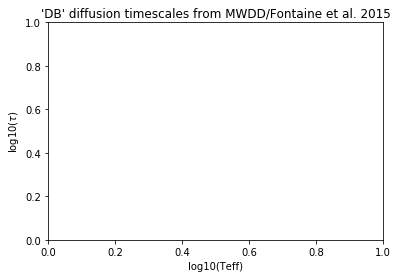

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
import periodictable as pt

from mendeleev import O, Ca, Li, Na, Si, Fe, Mg, He
start = time.time()

#import wdatmos
import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
import abundance_corrections as acorr
import interp_tau as itau
#print(os.getcwd())

In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
os.chdir(target_dir)

In [3]:
wd_abund_file='temp_wd_abundances.csv'
lodders_abund_file='Lodders2009_solarsystem_abundances.csv'

In [4]:
wd_abund_table=Table.read(wd_abund_file)
lodders_table=Table.read(lodders_abund_file)
lodders_table.add_index('element')
wd_abund_table.add_index('name')


In [5]:
meteor_Ali= 3.28
meteor_Ali_err= 0.05
meteor_FeH=0.
meteor_FeH_err=0.

Ok, now I want to implement a function that will get the slope of the line following equation (1) of paper III (Blouin et al. 2019) 

In [6]:
def get_slope(row):
    return (10**row['tau_ca/tau_li']-1)/(10**row['tau_ca/tau_na']-1)

def get_slope_alt(row):
    return (10**row['tau_ca/tau_li_alt']-1)/(10**row['tau_ca/tau_na_alt']-1)

def get_LiCa_vals(row, NaCa_vals, slope):
    return slope*(NaCa_vals-( row['na/he']-row['ca/he']))+row['li/he']-row['ca/he']

0.0 -1.7
-3.02607741818 -1.07070707071
0.3 -1.5
-3.02221571989 -0.908080808081
1.1 -2.3
-3.04242115059 0.505050505051
0.0 -1.7
-3.02607741818 -1.07070707071
<type 'numpy.float64'>


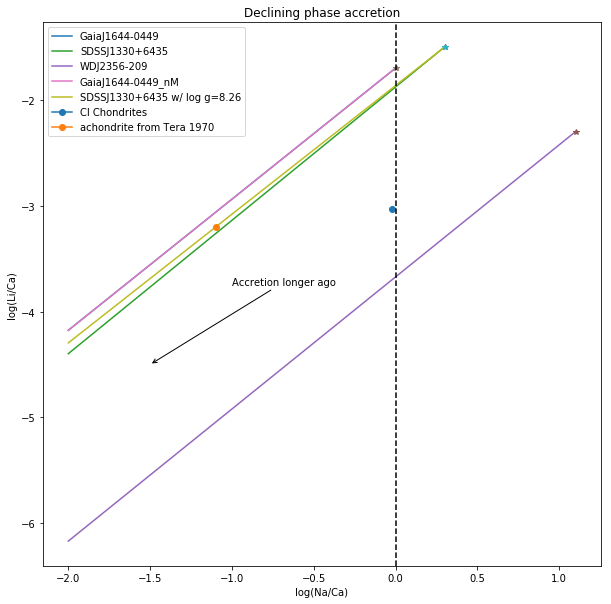

In [7]:
#NaCa_vals=np.linspace(-2.0, 1.5, 100)
plt.figure(figsize=(10,10))
for row in wd_abund_table:
    NaCa_vals=np.linspace(-2.0, row['na/he']-row['ca/he'], 100)
    slope=get_slope(row)
    LiCa_vals=get_LiCa_vals(row, NaCa_vals, slope)
    plt.plot(NaCa_vals, LiCa_vals, label=row['name'])
    plt.plot(row['na/he']-row['ca/he'],row['li/he']-row['ca/he'], marker='*')
    print(row['na/he']-row['ca/he'],row['li/he']-row['ca/he'])
    min_index=np.argmin(np.abs(LiCa_vals-(lodders_table.loc['Li']['A_el']-lodders_table.loc['Ca']['A_el'])))
    print(LiCa_vals[min_index], NaCa_vals[min_index])

j1330_row=wd_abund_table.loc['SDSSJ1330+6435']
j1330_slope=get_slope_alt(j1330_row)
NaCa_vals=np.linspace(-2.0, j1330_row['na/he']-j1330_row['ca/he'], 100)
LiCa_vals=get_LiCa_vals(j1330_row, NaCa_vals, j1330_slope)
plt.plot(NaCa_vals, LiCa_vals, label=j1330_row['name']+ ' w/ log g=8.26')
plt.plot(j1330_row['na/he']-j1330_row['ca/he'],j1330_row['li/he']-j1330_row['ca/he'], marker='*')

print(type(lodders_table.loc['Na']['A_el']-lodders_table.loc['Ca']['A_el']))
plt.plot(lodders_table.loc['Na']['A_el']-lodders_table.loc['Ca']['A_el'], lodders_table.loc['Li']['A_el']-lodders_table.loc['Ca']['A_el'], label='CI Chondrites', marker='o')
plt.plot(-1.1, -3.2, label='achondrite from Tera 1970', marker='o')
plt.legend(loc='best')
plt.xlabel('log(Na/Ca)')
plt.ylabel('log(Li/Ca)')
plt.axvline(x=0, linestyle='--', color='k')
plt.annotate('Accretion longer ago',xy=(-1.5, -4.5),xytext=(-1, -3.75), arrowprops=dict(arrowstyle='->'))
plt.title('Declining phase accretion')
plt.show()

In [8]:
print(lodders_table.loc['Li']['A_el'])

3.28


I'd also like to put points on that plot that correspond to the assumption of steady-state accretion

In [9]:
def get_SSP(el1, el2, row):
    el1_el2=row[el1+'/he']-row[el2+'/he']
    el1_el2=el1_el2+row['tau_'+el2+'/tau_'+ el1]
    return el1_el2

0.0 -1.7
-3.02607741818 -1.07070707071
0.3 -1.5
-3.02221571989 -0.908080808081
1.1 -2.3
-3.04242115059 0.505050505051
0.0 -1.7
-3.02607741818 -1.07070707071
<type 'numpy.float64'>


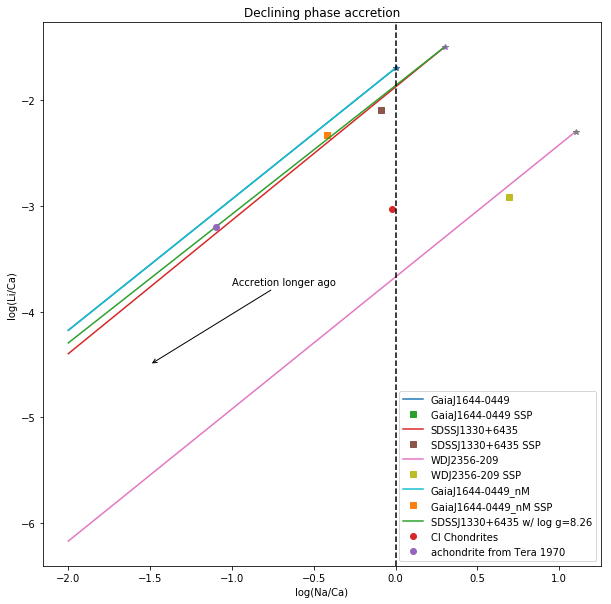

In [10]:
plt.figure(figsize=(10,10))
for row in wd_abund_table:
    NaCa_vals=np.linspace(-2.0, row['na/he']-row['ca/he'], 100)
    slope=get_slope(row)
    LiCa_vals=get_LiCa_vals(row, NaCa_vals, slope)
    plt.plot(NaCa_vals, LiCa_vals, label=row['name'])
    plt.plot(row['na/he']-row['ca/he'],row['li/he']-row['ca/he'], marker='*', linestyle='none')
    plt.plot(get_SSP('na','ca',row),get_SSP('li','ca',row),marker='s',label=row['name']+' SSP', linestyle='none')
    print(row['na/he']-row['ca/he'],row['li/he']-row['ca/he'])
    min_index=np.argmin(np.abs(LiCa_vals-(lodders_table.loc['Li']['A_el']-lodders_table.loc['Ca']['A_el'])))
    print(LiCa_vals[min_index], NaCa_vals[min_index])

j1330_row=wd_abund_table.loc['SDSSJ1330+6435']
j1330_slope=get_slope_alt(j1330_row)
NaCa_vals=np.linspace(-2.0, j1330_row['na/he']-j1330_row['ca/he'], 100)
LiCa_vals=get_LiCa_vals(j1330_row, NaCa_vals, j1330_slope)
plt.plot(NaCa_vals, LiCa_vals, label=j1330_row['name']+ ' w/ log g=8.26')
#plt.plot(j1330_row['na/he']-j1330_row['ca/he'],j1330_row['li/he']-j1330_row['ca/he'], marker='*')

print(type(lodders_table.loc['Na']['A_el']-lodders_table.loc['Ca']['A_el']))
plt.plot(lodders_table.loc['Na']['A_el']-lodders_table.loc['Ca']['A_el'], lodders_table.loc['Li']['A_el']-lodders_table.loc['Ca']['A_el'], label='CI Chondrites', marker='o', linestyle='none')
plt.plot(-1.1, -3.2, label='achondrite from Tera 1970', marker='o', linestyle='none')
plt.legend(loc='best')
plt.xlabel('log(Na/Ca)')
plt.ylabel('log(Li/Ca)')
plt.axvline(x=0, linestyle='--', color='k')
plt.annotate('Accretion longer ago',xy=(-1.5, -4.5),xytext=(-1, -3.75), arrowprops=dict(arrowstyle='->'))
plt.title('Declining phase accretion')
plt.show()

In [11]:
get_LiCa_vals(wd_abund_table.loc['SDSSJ1330+6435'], lodders_table.loc['Na']['A_el']-lodders_table.loc['Ca']['A_el'], j1330_slope)

-1.8890169615430477

In [12]:
get_LiCa_vals(wd_abund_table.loc['SDSSJ1330+6435'], -1.1, j1330_slope)

-3.2019492067508324

In [13]:
get_LiCa_vals(wd_abund_table.loc['GaiaJ1644-0449'], -1.1, j1330_slope)

-3.0372458053042237

In [14]:
j1644_mHe= 10.**wd_abund_table.loc['GaiaJ1644-0449']['log_q']*0.45 *u.solMass
print(j1644_mHe)


1.91960783461e-05 solMass


In [15]:
j1644_mCa= 10**wd_abund_table.loc['GaiaJ1644-0449']['ca/he'] * j1644_mHe
print(j1644_mCa)

6.07033297166e-15 solMass


In [16]:
j1644_mAcc_chond=j1644_mCa/(9220./1e6)
print(j1644_mAcc_chond.to(u.kg))

1.30918740532e+18 kg


In [17]:
print(j1644_mAcc_chond.to(u.earthMass))

2.1920754415e-07 earthMass


In [18]:
print(j1644_mCa.to(u.g))

1.20707078771e+19 g


In [19]:
def get_acc_mass(m_WD,wd_name, enrichment_factor=0):
    wd_mHe= 10.**wd_abund_table.loc[wd_name]['log_q']*m_WD *u.solMass
    wd_mCa=10**(wd_abund_table.loc[wd_name]['ca/he']+enrichment_factor) * wd_mHe
    wd_acc_mass=wd_mCa/(9220.e-6) #CI chondrite mass abundance of Calcium from Lodders et al. 2009
    return wd_acc_mass

In [20]:
print(get_acc_mass(0.74,'SDSSJ1330+6435').to(u.earthMass))

1.89179774088e-06 earthMass


In [21]:
print(get_acc_mass(0.74,'SDSSJ1330+6435').to(u.g))

1.12985061047e+22 g


In [22]:
print(get_acc_mass(0.45,'GaiaJ1644-0449').to(u.g))

1.30918740532e+21 g


In [23]:
print(get_acc_mass(0.56,'WDJ2356-209').to(u.g))

2.70381723392e+20 g


In [24]:
print(get_acc_mass(0.74,'SDSSJ1330+6435', enrichment_factor=1).to(u.g))
print(get_acc_mass(0.45,'GaiaJ1644-0449', enrichment_factor=1).to(u.g))
print(get_acc_mass(0.56,'WDJ2356-209', enrichment_factor=1).to(u.g))
print(get_acc_mass(0.45,'GaiaJ1644-0449_nM', enrichment_factor=1).to(u.g))

1.12985061047e+23 g
1.30918740532e+22 g
2.70381723392e+21 g
4.04577585897e+21 g


In [25]:
print(get_acc_mass(0.74,'SDSSJ1330+6435', enrichment_factor=1).to(u.earthMass))
print(get_acc_mass(0.45,'GaiaJ1644-0449', enrichment_factor=1).to(u.earthMass))
print(get_acc_mass(0.56,'WDJ2356-209', enrichment_factor=1).to(u.earthMass))
print(get_acc_mass(0.56,'GaiaJ1644-0449_nM', enrichment_factor=1).to(u.earthMass))

1.89179774088e-05 earthMass
2.1920754415e-06 earthMass
4.5272138524e-07 earthMass
8.43006667948e-07 earthMass


In [26]:
print(get_acc_mass(0.74,'SDSSJ1330+6435', enrichment_factor=1).to(u.kg))
print(get_acc_mass(0.45,'GaiaJ1644-0449', enrichment_factor=1).to(u.kg))
print(get_acc_mass(0.56,'WDJ2356-209', enrichment_factor=1).to(u.kg))
print(get_acc_mass(0.56,'GaiaJ1644-0449_nM', enrichment_factor=1).to(u.kg))

1.12985061047e+20 kg
1.30918740532e+19 kg
2.70381723392e+18 kg
5.03474329116e+18 kg


In [27]:
np.log10(1.230)

0.089905111439397931

In [28]:
print(u.solMass.to(u.kg))

1.98847541534e+30


In [29]:
print(10.**(-1.16))
print(10.**(-1.09))

0.0691830970919
0.0812830516164


In [30]:
def get_acc_mass_acorr(m_wd, wd_name, desired_NaCa, Na_mass_frac, Ca_mass_frac, logg=8.0, cross_extrap=False):
    t_NaCa=acorr.get_time_since_accretion(wd_abund_table.loc[wd_name]['teff'],wd_abund_table.loc[wd_name]['na/he']-wd_abund_table.loc[wd_name]['ca/he'], desired_NaCa,'Na', 'Ca',logg=logg ,cross_extrap=cross_extrap)
    log_mCa= acorr.get_accreted_mass('Ca', wd_abund_table.loc[wd_name]['ca/he'], t_NaCa,  teff=wd_abund_table.loc[wd_name]['teff'], logg=logg, log_q=wd_abund_table.loc[wd_name]['log_q'], m_wd=m_wd, cross_extrap=cross_extrap)
    log_mNa= acorr.get_accreted_mass('Na', wd_abund_table.loc[wd_name]['na/he'], t_NaCa,  teff=wd_abund_table.loc[wd_name]['teff'], logg=logg, log_q=wd_abund_table.loc[wd_name]['log_q'], m_wd=m_wd, cross_extrap=cross_extrap)
    mNa=10**log_mNa
    mCa=10**log_mCa
    mtotal_from_Na= mNa/Na_mass_frac
    mtotal_from_Ca= mCa/Ca_mass_frac
    print('Name:',wd_name)
    print('time since accretion', t_NaCa*1e-6, 'Myr')
    print('total accreted mass from Na', mtotal_from_Na, 'kg')
    print('total accreted mass from Ca', mtotal_from_Ca, 'kg')
    print('log(Na/Ca) worked back',np.log10(pt.elements[cp.el_nums['Ca']].mass/pt.elements[cp.el_nums['Na']].mass*mNa/mCa))
    print('desired_NaCa', desired_NaCa)
    #print('so those should be the same...')
    return mtotal_from_Ca

In [31]:
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -1.1, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', 0.0,0.005,  0.009)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -1.1, 0.0033, 0.073, logg=7.5)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', 0.0,0.005,  0.009, logg=7.5)
print('\n\n\n*****')



Name: GaiaJ1644-0449
time since accretion 2.40925491078 Myr
total accreted mass from Na 9.78978651383e+19 kg
total accreted mass from Ca 9.71260474629e+19 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449
time since accretion -0.0 Myr
total accreted mass from Na 1.38661199805e+19 kg
total accreted mass from Ca 1.34293150721e+19 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****
Name: GaiaJ1644-0449
time since accretion 151.063172114 Myr
total accreted mass from Na 3.65542588869e+20 kg
total accreted mass from Ca 3.62660685052e+20 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449
time since accretion -0.0 Myr
total accreted mass from Na 1.38661199805e+19 kg
total accreted mass from Ca 1.34293150721e+19 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****


In [32]:
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', -1.0, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', 0.0,0.005,  0.009)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', -1.0, 0.0033, 0.073, logg=7.5)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', 0.0,0.005,  0.009, logg=7.5)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', 0.02,0.005,  0.009, logg=7.5)





Name: GaiaJ1644-0449_nM
time since accretion 2.19023173707 Myr
total accreted mass from Na 3.27332052869e+19 kg
total accreted mass from Ca 2.57959204196e+19 kg
log(Na/Ca) worked back -1.0
desired_NaCa -1.0



*****
Name: GaiaJ1644-0449_nM
time since accretion -0.0 Myr
total accreted mass from Na 5.3324951235e+18 kg
total accreted mass from Ca 5.16451301697e+18 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****
Name: GaiaJ1644-0449_nM
time since accretion 137.330156467 Myr
total accreted mass from Na 1.08427218747e+20 kg
total accreted mass from Ca 8.54477855624e+19 kg
log(Na/Ca) worked back -1.0
desired_NaCa -1.0



*****
Name: GaiaJ1644-0449_nM
time since accretion -0.0 Myr
total accreted mass from Na 5.3324951235e+18 kg
total accreted mass from Ca 5.16451301697e+18 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****
Name: GaiaJ1644-0449_nM
time since accretion -2.74660312935 Myr
total accreted mass from Na 5.06262117442e+18 kg
total accreted mass

4.6824628524380621e+18

In [33]:
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', -1.0, 0.0033, 0.073)
print('\n\n\n***************')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', 0.0,0.005,  0.009)

Name: GaiaJ1644-0449_nM
time since accretion 2.19023173707 Myr
total accreted mass from Na 3.27332052869e+19 kg
total accreted mass from Ca 2.57959204196e+19 kg
log(Na/Ca) worked back -1.0
desired_NaCa -1.0



***************
Name: GaiaJ1644-0449_nM
time since accretion -0.0 Myr
total accreted mass from Na 5.3324951235e+18 kg
total accreted mass from Ca 5.16451301697e+18 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0


5.1645130169664584e+18

In [34]:
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', -1.0, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435',0.0,0.005,  0.009)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', -1.0, 0.0033, 0.073, logg=8.5)
print('\n\n\n*****')

get_acc_mass_acorr(0.74, 'SDSSJ1330+6435',0.0,0.005,  0.009, logg=8.5)
print('\n\n\n*****')

get_acc_mass_acorr(0.56, 'SDSSJ1330+6435', -1.0, 0.0033, 0.073)




Name: SDSSJ1330+6435
time since accretion 3.3307592103 Myr
total accreted mass from Na 2.75226880145e+21 kg
total accreted mass from Ca 2.16896898282e+21 kg
log(Na/Ca) worked back -1.0
desired_NaCa -1.0



*****
Name: SDSSJ1330+6435
time since accretion 0.768636740839 Myr
total accreted mass from Na 3.81366021147e+20 kg
total accreted mass from Ca 3.69352382858e+20 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****
Name: SDSSJ1330+6435
time since accretion 0.0959630424351 Myr
total accreted mass from Na 3.40320020496e+21 kg
total accreted mass from Ca 2.68194577616e+21 kg
log(Na/Ca) worked back -1.0
desired_NaCa -1.0



*****
Name: SDSSJ1330+6435
time since accretion 0.022145317485 Myr
total accreted mass from Na 4.00514410058e+20 kg
total accreted mass from Ca 3.87897566959e+20 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****
Name: SDSSJ1330+6435
time since accretion 3.3307592103 Myr
total accreted mass from Na 2.08279801191e+21 kg
total accrete

1.6413819329439927e+21

In [35]:
get_acc_mass_acorr(0.56, 'WDJ2356-209', -1.0, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'WDJ2356-209',0.0,0.005,  0.009)
print('\n\n\n*****')


Name: WDJ2356-209
time since accretion 4.93457729013 Myr
total accreted mass from Na 1.19484462411e+21 kg
total accreted mass from Ca 9.41616214091e+20 kg
log(Na/Ca) worked back -1.0
desired_NaCa -1.0



*****
Name: WDJ2356-209
time since accretion 2.58477858054 Myr
total accreted mass from Na 1.81466261473e+20 kg
total accreted mass from Ca 1.75749784634e+20 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****


I need to check that the mass fractions I'm using for the recovery attempts are actually the correct ones that would produce the relative abundance that I'd track back to

In [36]:
-1.0, 0.0033, 0.073

(-1.0, 0.0033, 0.073)

In [37]:
naca_mass=  0.0033/0.073

In [38]:
naca_num=naca_mass*pt.Ca.mass/pt.Na.mass

In [39]:
print(naca_num)
print(np.log10(naca_num))

0.0788065824704
-1.10343750572


Yep. They don't match up. I should be using -1.1 probably.

In [40]:
achond_naca=-1.1
chond_naca=-0.01

In [41]:
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', achond_naca, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', achond_naca, 0.0033, 0.073, logg=7.5)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', chond_naca,0.005,  0.009, logg=7.5)

Name: GaiaJ1644-0449_nM
time since accretion 2.40925491078 Myr
total accreted mass from Na 3.76485916165e+19 kg
total accreted mass from Ca 3.73517736172e+19 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449_nM
time since accretion 151.063172114 Myr
total accreted mass from Na 1.40576749322e+20 kg
total accreted mass from Ca 1.39468455288e+20 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449_nM
time since accretion 1.37330156467 Myr
total accreted mass from Na 5.47277993091e+18 kg
total accreted mass from Ca 5.42384030755e+18 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01


5.4238403075548129e+18

In [42]:
get_acc_mass_acorr(0.56, 'WDJ2356-209', achond_naca, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'WDJ2356-209', -0.01,0.005,  0.009, logg=8.0)



Name: WDJ2356-209
time since accretion 5.16955716109 Myr
total accreted mass from Na 1.38394038157e+21 kg
total accreted mass from Ca 1.37302952415e+21 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: WDJ2356-209
time since accretion 2.60827656764 Myr
total accreted mass from Na 1.84152019906e+20 kg
total accreted mass from Ca 1.82505264398e+20 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01


1.8250526439767219e+20

## 2020-01-25 Attempt for the actually correct abundances

In [43]:
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', achond_naca, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', achond_naca, 0.0033, 0.073, logg=7.5)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', chond_naca, 0.005,  0.009)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', chond_naca, 0.005,  0.009, logg=7.5)
print('\n\n\n*****')

Name: GaiaJ1644-0449
time since accretion 2.40925491078 Myr
total accreted mass from Na 9.78978651383e+19 kg
total accreted mass from Ca 9.71260474629e+19 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449
time since accretion 151.063172114 Myr
total accreted mass from Na 3.65542588869e+20 kg
total accreted mass from Ca 3.62660685052e+20 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449
time since accretion 0.0219023173707 Myr
total accreted mass from Na 1.40614780662e+19 kg
total accreted mass from Ca 1.39357351259e+19 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****
Name: GaiaJ1644-0449
time since accretion 1.37330156467 Myr
total accreted mass from Na 1.4230903431e+19 kg
total accreted mass from Ca 1.41036454264e+19 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****


In [44]:
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', achond_naca, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'GaiaJ1644-0449_nM', chond_naca, 0.005,  0.009)
print('\n\n\n*****')


Name: GaiaJ1644-0449_nM
time since accretion 2.40925491078 Myr
total accreted mass from Na 3.76485916165e+19 kg
total accreted mass from Ca 3.73517736172e+19 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: GaiaJ1644-0449_nM
time since accretion 0.0219023173707 Myr
total accreted mass from Na 5.40762400173e+18 kg
total accreted mass from Ca 5.35926702681e+18 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****


In [45]:
get_acc_mass_acorr(0.56, 'WDJ2356-209', achond_naca, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.56, 'WDJ2356-209', chond_naca, 0.005,  0.009)
print('\n\n\n*****')



Name: WDJ2356-209
time since accretion 5.16955716109 Myr
total accreted mass from Na 1.38394038157e+21 kg
total accreted mass from Ca 1.37302952415e+21 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: WDJ2356-209
time since accretion 2.60827656764 Myr
total accreted mass from Na 1.84152019906e+20 kg
total accreted mass from Ca 1.82505264398e+20 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****


In [46]:
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', achond_naca, 0.0033, 0.073)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', chond_naca, 0.005,  0.009)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', achond_naca, 0.0033, 0.073, logg=8.5)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', chond_naca, 0.005,  0.009, logg=8.5)
print('\n\n\n*****')



Name: SDSSJ1330+6435
time since accretion 3.58697145725 Myr
total accreted mass from Na 3.21721530357e+21 kg
total accreted mass from Ca 3.19185107695e+21 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: SDSSJ1330+6435
time since accretion 0.794257965534 Myr
total accreted mass from Na 3.87365486784e+20 kg
total accreted mass from Ca 3.83901521255e+20 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****
Name: SDSSJ1330+6435
time since accretion 0.10334481493 Myr
total accreted mass from Na 4.04360595567e+21 kg
total accreted mass from Ca 4.01172654191e+21 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
Name: SDSSJ1330+6435
time since accretion 0.0228834947345 Myr
total accreted mass from Na 4.07479982664e+20 kg
total accreted mass from Ca 4.0383614587e+20 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****


In [47]:
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -1.1, 0.0033, 0.073, cross_extrap=True, logg=7.77)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', 0.0,0.005,  0.009, cross_extrap=True, logg=7.77)
print('\n\n\n*****')



cross_extrap
Name: GaiaJ1644-0449
time since accretion 15.8297949934 Myr
total accreted mass from Na 1.55666094115e+20 kg
total accreted mass from Ca 1.54438837089e+20 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
cross_extrap
Name: GaiaJ1644-0449
time since accretion -0.0 Myr
total accreted mass from Na 1.38661199805e+19 kg
total accreted mass from Ca 1.34293150721e+19 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****


In [48]:
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', achond_naca, 0.0033, 0.073, logg=8.26, cross_extrap=True)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', chond_naca, 0.005,  0.009, logg=8.26, cross_extrap=True)
print('\n\n\n*****')

cross_extrap
Name: SDSSJ1330+6435
time since accretion 0.566860382904 Myr
total accreted mass from Na 3.6087993486e+21 kg
total accreted mass from Ca 3.58034790974e+21 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
cross_extrap
Name: SDSSJ1330+6435
time since accretion 0.125519084786 Myr
total accreted mass from Na 3.97343724825e+20 kg
total accreted mass from Ca 3.937905302e+20 kg
log(Na/Ca) worked back -0.01
desired_NaCa -0.01



*****


doing simultaneous decline
cross_extrap
3838.50962859 7.55032511167
3838.50962859 7.55032511167
3838.50962859 7.55032511167
3838.50962859 7.55032511167
GaiaJ1644-0449 mean log(Li/Ca) -1.80773482581 +/- 0.28633803918
GaiaJ1644-0449 median log(Li/Ca) -1.8071530424 up/down -1.52930625834 -2.08233162239
mean t_decline 15.0260305639 Myr


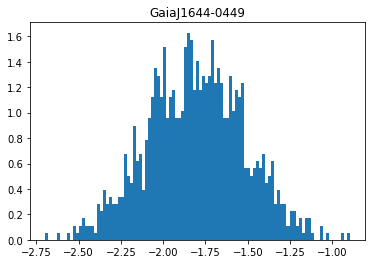

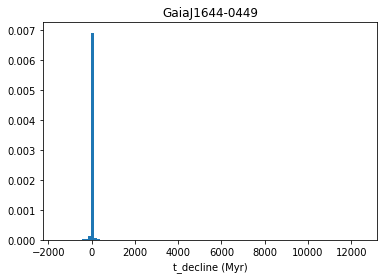

doing simultaneous decline
cross_extrap
4007.52350073 8.26952964736
4007.52350073 8.26952964736
4007.52350073 8.26952964736
4007.52350073 8.26952964736
SDSSJ1330+6435 mean log(Li/Ca) -1.94466407937 +/- 0.676544930283
SDSSJ1330+6435 median log(Li/Ca) -1.96176169616 up/down -1.26587593062 -2.59392046613
mean t_decline 0.221370938417 Myr


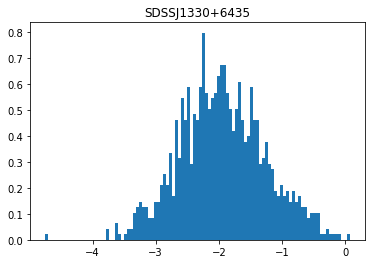

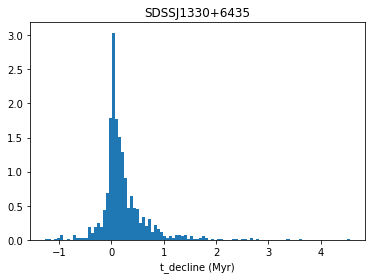

doing simultaneous decline
cross_extrap
4167.44946244 7.8360161589
4167.44946244 7.8360161589
4167.44946244 7.8360161589
4167.44946244 7.8360161589
WDJ2356-209 mean log(Li/Ca) -3.71124946858 +/- 0.264250694282
WDJ2356-209 median log(Li/Ca) -3.71799163749 up/down -3.45576712375 -3.97773584263
mean t_decline 3.58270463315 Myr


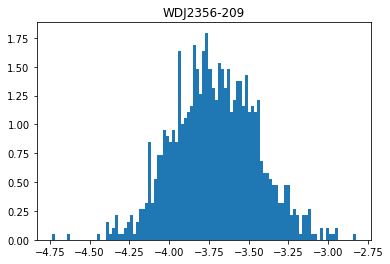

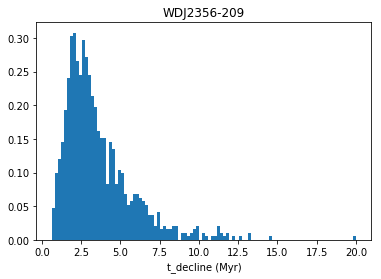

doing simultaneous decline
cross_extrap
3633.25092013 7.7274605841
3633.25092013 7.7274605841
3633.25092013 7.7274605841
3633.25092013 7.7274605841
GaiaJ1644-0449_nM mean log(Li/Ca) -1.81859502071 +/- 0.286450056207
GaiaJ1644-0449_nM median log(Li/Ca) -1.81020848219 up/down -1.53459996376 -2.10983373976
mean t_decline 6.77507841727 Myr


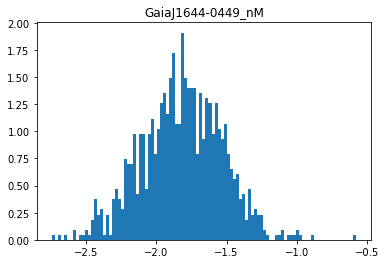

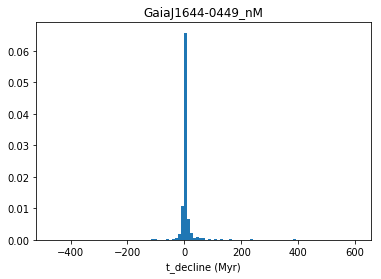

In [49]:
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -0.01, int(1e3), plot_all=True)

In [50]:
#for row in wd_abund_table:
#    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -1.1, int(1e3), plot_all=True)

In [51]:
#for row in wd_abund_table:
#    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -1.1, int(1e6), plot_all=True)

In [52]:
#for row in wd_abund_table:
#    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -0.01, int(1e6), plot_all=True)

In [53]:

#Primitive Earth Mantle
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -0.738,0.0026, 0.0248, cross_extrap=True, logg=7.77)
print('\n\n\n*****')
#bulk Earth
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -0.639, 0.002201, 0.0167, cross_extrap=True, logg=7.77)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -1.1, 0.0033, 0.073, cross_extrap=True, logg=7.77)
print('\n\n\n*****')
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', 0.0,0.005,  0.009, cross_extrap=True, logg=7.77)
print('\n\n\n*****')
#Angra dos Reis
get_acc_mass_acorr(0.45, 'GaiaJ1644-0449', -2.55,0.000264, 0.1648, cross_extrap=True, logg=7.77)



cross_extrap
Name: GaiaJ1644-0449
time since accretion 10.6203533683 Myr
total accreted mass from Na 1.02210835612e+20 kg
total accreted mass from Ca 1.02185675571e+20 kg
log(Na/Ca) worked back -0.738
desired_NaCa -0.738



*****
cross_extrap
Name: GaiaJ1644-0449
time since accretion 9.19567181891 Myr
total accreted mass from Na 1.00825358135e+20 kg
total accreted mass from Ca 1.008892188e+20 kg
log(Na/Ca) worked back -0.639
desired_NaCa -0.639



*****
cross_extrap
Name: GaiaJ1644-0449
time since accretion 15.8297949934 Myr
total accreted mass from Na 1.55666094115e+20 kg
total accreted mass from Ca 1.54438837089e+20 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
cross_extrap
Name: GaiaJ1644-0449
time since accretion -0.0 Myr
total accreted mass from Na 1.38661199805e+19 kg
total accreted mass from Ca 1.34293150721e+19 kg
log(Na/Ca) worked back 5.78596479932e-16
desired_NaCa 0.0



*****
cross_extrap
Name: GaiaJ1644-0449
time since accretion 36.6963429393 Myr
total accreted

2.7018070180882704e+22

In [54]:

#Primitive Earth Mantle
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', -0.738,0.0026, 0.0248, cross_extrap=True, logg=8.26)
print('\n\n\n*****')
#bulk Earth
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', -0.639, 0.002201, 0.0167, cross_extrap=True, logg=8.26)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', -1.1, 0.0033, 0.073, cross_extrap=True, logg=8.26)
print('\n\n\n*****')
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', 0.0,0.005,  0.009, cross_extrap=True, logg=8.26)
print('\n\n\n*****')
#Angra dos Reis
get_acc_mass_acorr(0.74, 'SDSSJ1330+6435', -2.55,0.000264, 0.1648, cross_extrap=True, logg=8.26)



cross_extrap
Name: SDSSJ1330+6435
time since accretion 0.420286483896 Myr
total accreted mass from Na 2.5270155889e+21 kg
total accreted mass from Ca 2.52639354316e+21 kg
log(Na/Ca) worked back -0.738
desired_NaCa -0.738



*****
cross_extrap
Name: SDSSJ1330+6435
time since accretion 0.380201356819 Myr
total accreted mass from Na 2.53701145091e+21 kg
total accreted mass from Ca 2.53861834069e+21 kg
log(Na/Ca) worked back -0.639
desired_NaCa -0.639



*****
cross_extrap
Name: SDSSJ1330+6435
time since accretion 0.566860382904 Myr
total accreted mass from Na 3.6087993486e+21 kg
total accreted mass from Ca 3.58034790974e+21 kg
log(Na/Ca) worked back -1.1
desired_NaCa -1.1



*****
cross_extrap
Name: SDSSJ1330+6435
time since accretion 0.121470082051 Myr
total accreted mass from Na 3.90868908872e+20 kg
total accreted mass from Ca 3.78555914453e+20 kg
log(Na/Ca) worked back 4.82163733277e-16
desired_NaCa 0.0



*****
cross_extrap
Name: SDSSJ1330+6435
time since accretion 1.15396577948 Myr
t

4.8406040008020321e+23

doing simultaneous decline
cross_extrap
3625.5873394 7.69798109095
3625.5873394 7.69798109095
3625.5873394 7.69798109095
3625.5873394 7.69798109095
GaiaJ1644-0449 mean log(Li/Ca) -2.78188731926 +/- 0.300885838358
GaiaJ1644-0449 median log(Li/Ca) -2.77106500725 up/down -2.49716064891 -3.08328049973
mean t_decline 102.186627589 Myr


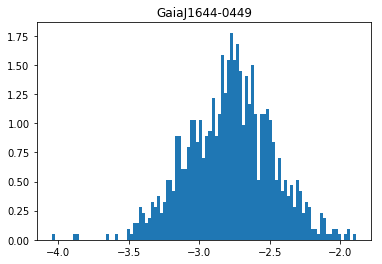

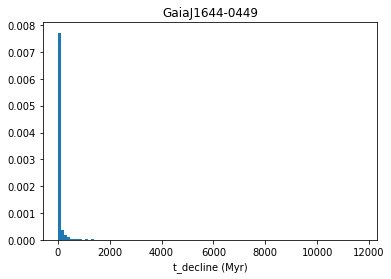

doing simultaneous decline
cross_extrap
4492.22379036 8.20712421059
4492.22379036 8.20712421059
4492.22379036 8.20712421059
4492.22379036 8.20712421059
SDSSJ1330+6435 mean log(Li/Ca) -2.89735282247 +/- 0.81286019782
SDSSJ1330+6435 median log(Li/Ca) -2.89390073133 up/down -2.21911803668 -3.52253948241
mean t_decline 0.716469872277 Myr


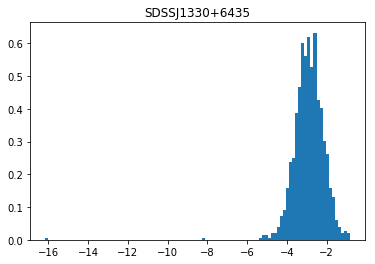

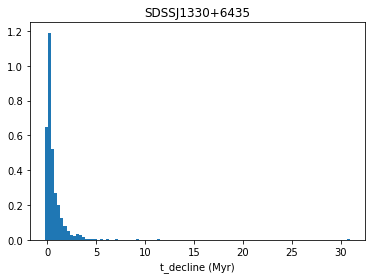

doing simultaneous decline
cross_extrap
4081.60843794 7.85586404556
4081.60843794 7.85586404556
4081.60843794 7.85586404556
4081.60843794 7.85586404556
WDJ2356-209 mean log(Li/Ca) -4.61989072014 +/- 0.267979217777
WDJ2356-209 median log(Li/Ca) -4.62273597324 up/down -4.36098074105 -4.89085550728
mean t_decline 6.09480502482 Myr


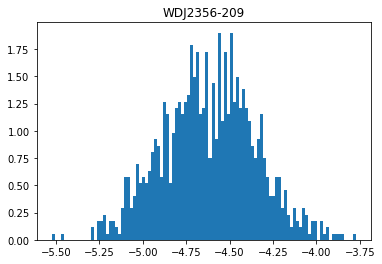

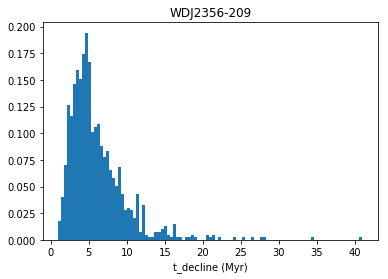

doing simultaneous decline
cross_extrap
4224.63041544 7.57656440506
4224.63041544 7.57656440506
4224.63041544 7.57656440506
4224.63041544 7.57656440506
GaiaJ1644-0449_nM mean log(Li/Ca) -2.80165381727 +/- 0.303886502482
GaiaJ1644-0449_nM median log(Li/Ca) -2.79517987917 up/down -2.50622861744 -3.10359478228
mean t_decline 87.2428710881 Myr


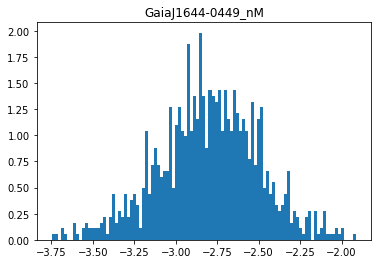

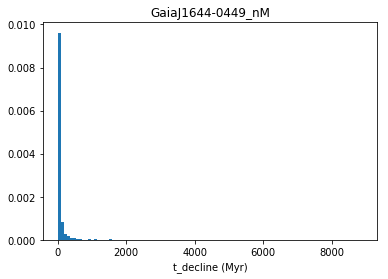

In [55]:
#Earth primitive mantle (Wang et al. 2018)
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -0.738, int(1e3), plot_all=True)

doing simultaneous decline
cross_extrap
3987.96781074 7.54667916104
3987.96781074 7.54667916104
3987.96781074 7.54667916104
3987.96781074 7.54667916104
GaiaJ1644-0449 mean log(Li/Ca) -2.63281282152 +/- 0.293915106941
GaiaJ1644-0449 median log(Li/Ca) -2.64362571474 up/down -2.32533816065 -2.91279015126
mean t_decline 59.486082181 Myr


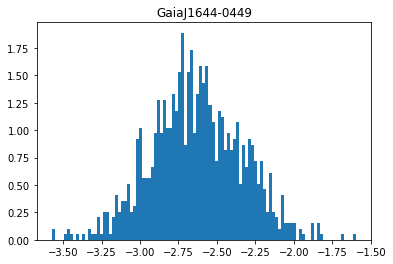

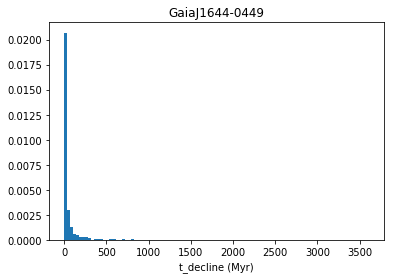

doing simultaneous decline
cross_extrap
4239.60843314 8.20296544566
4239.60843314 8.20296544566
4239.60843314 8.20296544566
4239.60843314 8.20296544566
SDSSJ1330+6435 mean log(Li/Ca) -2.75255672846 +/- 0.860159482367
SDSSJ1330+6435 median log(Li/Ca) -2.75882719043 up/down -2.09618660829 -3.39410781111
mean t_decline 0.651908513008 Myr


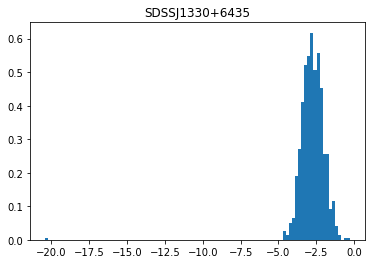

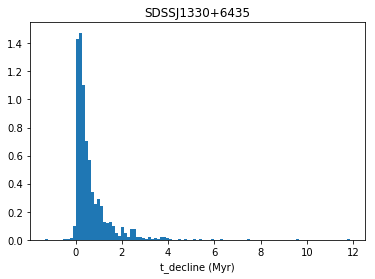

doing simultaneous decline
cross_extrap
4130.53773788 7.84055192336
4130.53773788 7.84055192336
4130.53773788 7.84055192336
4130.53773788 7.84055192336
WDJ2356-209 mean log(Li/Ca) -4.48159013402 +/- 0.271408636524
WDJ2356-209 median log(Li/Ca) -4.48480467235 up/down -4.21162474212 -4.74434215446
mean t_decline 5.49181729622 Myr


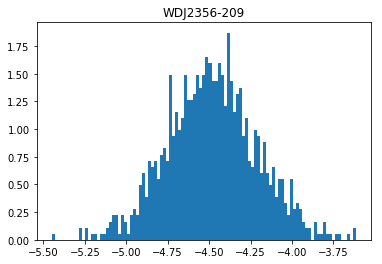

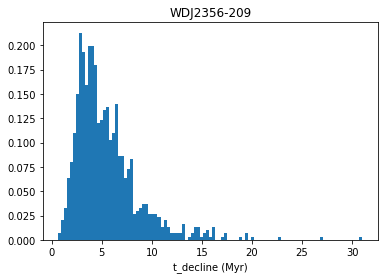

doing simultaneous decline
cross_extrap
3545.69516832 7.71853092035
3545.69516832 7.71853092035
3545.69516832 7.71853092035
3545.69516832 7.71853092035
GaiaJ1644-0449_nM mean log(Li/Ca) -2.66454036033 +/- 0.289550753489
GaiaJ1644-0449_nM median log(Li/Ca) -2.67162349974 up/down -2.37499929294 -2.94946719378
mean t_decline 67.1721449831 Myr


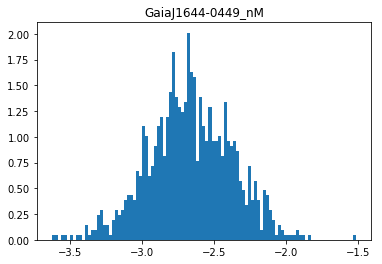

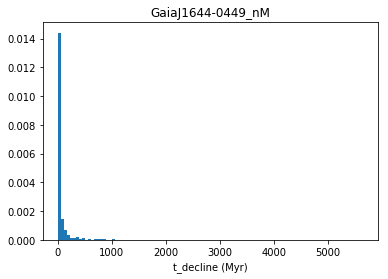

In [56]:
#Bulk Earth (Wang et al. 2018)
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -0.638, int(1e3), plot_all=True)

In [57]:
#repeat trial Bulk Earth (Wang et al. 2018)
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -0.638, int(1e3), plot_all=False)

doing simultaneous decline
cross_extrap
4147.37077808 8.16940760761
4147.37077808 8.16940760761
4147.37077808 8.16940760761
4147.37077808 8.16940760761
GaiaJ1644-0449 mean log(Li/Ca) -2.63351566295 +/- 0.298253904933
GaiaJ1644-0449 median log(Li/Ca) -2.63646440459 up/down -2.33248308978 -2.91647007533
mean t_decline 57.4786593213 Myr
doing simultaneous decline
cross_extrap
4286.52935813 8.26392947232
4286.52935813 8.26392947232
4286.52935813 8.26392947232
4286.52935813 8.26392947232
SDSSJ1330+6435 mean log(Li/Ca) -2.75202167597 +/- 0.679479375724
SDSSJ1330+6435 median log(Li/Ca) -2.72451567394 up/down -2.09428580375 -3.42391169301
mean t_decline 0.708683336078 Myr
doing simultaneous decline
cross_extrap
4047.22792418 8.07247025544
4047.22792418 8.07247025544
4047.22792418 8.07247025544
4047.22792418 8.07247025544
WDJ2356-209 mean log(Li/Ca) -4.48393677278 +/- 0.272404783455
WDJ2356-209 median log(Li/Ca) -4.49325132623 up/down -4.21563924517 -4.74158865377
mean t_decline 5.61572650261 M

doing simultaneous decline
cross_extrap
3850.23969653 7.60290105851
3850.23969653 7.60290105851
3850.23969653 7.60290105851
3850.23969653 7.60290105851
GaiaJ1644-0449 mean log(K/Ca) -1.29757990755 +/- 0.214552681279
GaiaJ1644-0449 median log(K/Ca) -1.30615025018 up/down -1.07471598827 -1.51586670252
mean t_decline 101.019765462 Myr


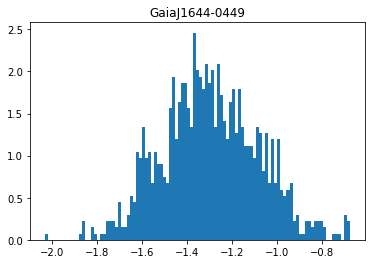

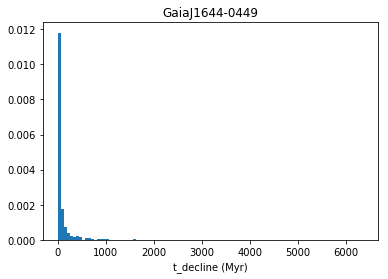

doing simultaneous decline
cross_extrap
4536.31709928 8.11702826751
4536.31709928 8.11702826751
4536.31709928 8.11702826751
4536.31709928 8.11702826751
SDSSJ1330+6435 mean log(K/Ca) 0.0919744642302 +/- 0.333348761703
SDSSJ1330+6435 median log(K/Ca) 0.116472695261 up/down 0.401528366302 -0.246421877398
mean t_decline 1.0037900043 Myr


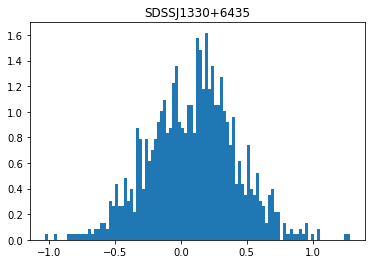

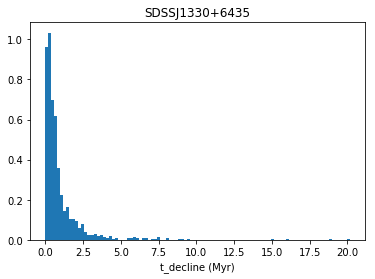

doing simultaneous decline
cross_extrap
4068.52657607 8.00993309596
4068.52657607 8.00993309596
4068.52657607 8.00993309596
4068.52657607 8.00993309596
WDJ2356-209 mean log(K/Ca) -0.5456735933 +/- 0.118809825258
WDJ2356-209 median log(K/Ca) -0.553497015883 up/down -0.427011040046 -0.662288943418
mean t_decline 7.17474173695 Myr


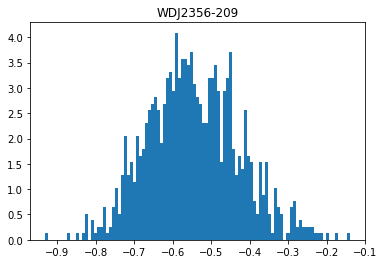

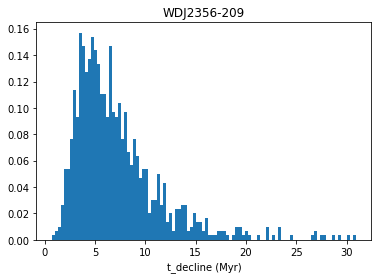

doing simultaneous decline
cross_extrap
3498.80297521 8.08797763316
3498.80297521 8.08797763316
3498.80297521 8.08797763316
3498.80297521 8.08797763316
GaiaJ1644-0449_nM mean log(K/Ca) -1.28691813022 +/- 0.220360457805
GaiaJ1644-0449_nM median log(K/Ca) -1.29009968129 up/down -1.0746591625 -1.50703122884
mean t_decline 82.8149795571 Myr


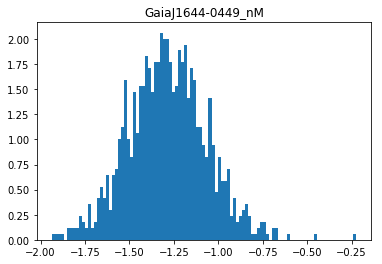

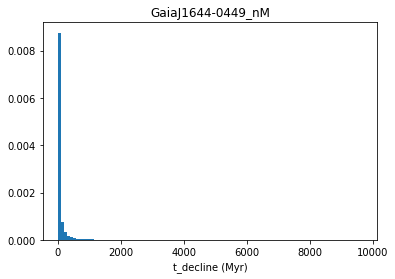

In [58]:
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'K', 'Ca','Na', -1.1, int(1e3), plot_all=True)

In [59]:
wd_abund_table.colnames

['name',
 'teff',
 'teff_err',
 'logg',
 'logg_err',
 'm_wd',
 'li/he',
 'li/he_err',
 'na/he',
 'na/he_err',
 'h/he',
 'h/he_err',
 'li/ca',
 'li/ca_err',
 'na/ca',
 'na/ca_err',
 'ca/he',
 'ca/he_err',
 'fe/he',
 'fe/he_err',
 'mg/he',
 'mg/he_err',
 'k/he',
 'k/he_err',
 'k/ca',
 'k/ca_err',
 'k/na',
 'k/na_err',
 'tau_ca/tau_li',
 'tau_ca/tau_na',
 'tau_ca/tau_li_alt',
 'tau_ca/tau_na_alt',
 'log_q',
 'dp_sioux_li/ca',
 'dp_sioux_li/ca_err',
 'dp_chond_li/ca',
 'dp_chond_li/ca_err',
 'dp_p_mantle_li/ca',
 'dp_p_mantle_li/ca_err',
 'dp_bulk_earth_li/ca',
 'dp_bulk_earth_li/ca_err',
 'dp_crust_li/ca',
 'dp_crust_li/ca_err',
 'dp_angra_li/ca',
 'dp_angra_li/ca_err',
 'dp_bulk_mars_li/ca',
 'dp_bulk_mars_li/ca_err',
 'dp_chassigny_li/ca',
 'dp_chassigny_li/ca_err',
 'dp_highk_moon_li/ca',
 'dp_highk_moon_li/ca_err',
 'age',
 'age_minus',
 'age_plus',
 'age_lowz',
 'age_minus_lowz',
 'age_plus_lowz',
 'li/h',
 'ALi_direct',
 'Ali_lo_direct']

doing simultaneous decline
cross_extrap
3612.18157565 7.96147324575
3612.18157565 7.96147324575
3612.18157565 7.96147324575
3612.18157565 7.96147324575
GaiaJ1644-0449 mean log(Li/Ca) -1.80794924205 +/- 0.282707448509
GaiaJ1644-0449 median log(Li/Ca) -1.79896000943 up/down -1.53153861142 -2.08650618674
mean t_decline 4.54044778823 Myr


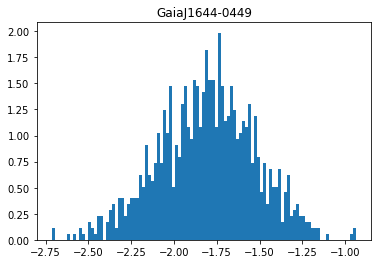

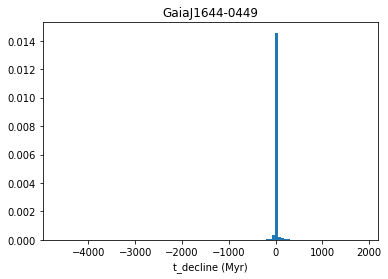

doing simultaneous decline
cross_extrap
4341.08640917 8.12679416289
4341.08640917 8.12679416289
4341.08640917 8.12679416289
4341.08640917 8.12679416289
SDSSJ1330+6435 mean log(Li/Ca) -1.88711498957 +/- 0.657464585096
SDSSJ1330+6435 median log(Li/Ca) -1.86273222973 up/down -1.22396152351 -2.51016474375
mean t_decline 0.226739826307 Myr


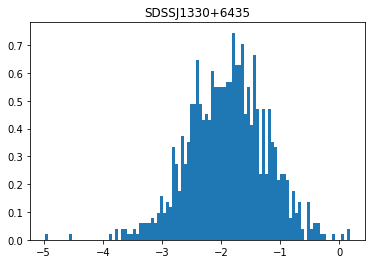

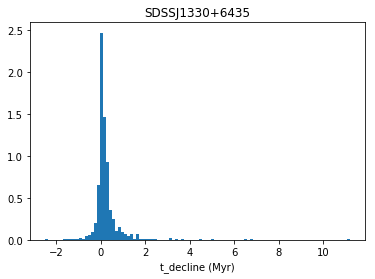

doing simultaneous decline
cross_extrap
4039.92273496 7.91708664926
4039.92273496 7.91708664926
4039.92273496 7.91708664926
4039.92273496 7.91708664926
WDJ2356-209 mean log(Li/Ca) -3.66926501747 +/- 0.274158045451
WDJ2356-209 median log(Li/Ca) -3.66417112889 up/down -3.40335200215 -3.93184931329
mean t_decline 3.51416916121 Myr


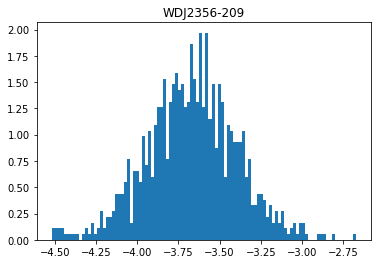

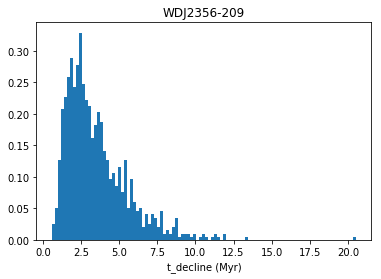

doing simultaneous decline
cross_extrap
3517.86903423 7.94155452626
3517.86903423 7.94155452626
3517.86903423 7.94155452626
3517.86903423 7.94155452626
GaiaJ1644-0449_nM mean log(Li/Ca) -1.79654895167 +/- 0.282581865609
GaiaJ1644-0449_nM median log(Li/Ca) -1.79711317062 up/down -1.51164139334 -2.07804135841
mean t_decline 6.04282234276 Myr


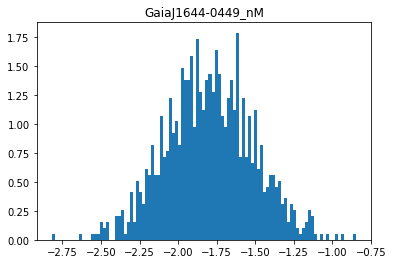

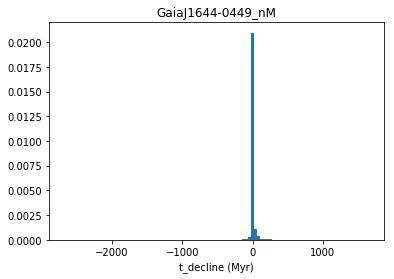

In [60]:
#Earth Crust from Rumble et al. 2019
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na',0.0 , int(1e3), plot_all=True)

doing simultaneous decline
cross_extrap
3958.55173824 7.86293074587
3958.55173824 7.86293074587
3958.55173824 7.86293074587
3958.55173824 7.86293074587
GaiaJ1644-0449 mean log(Li/Ca) -5.15531993887 +/- 0.338026902614
GaiaJ1644-0449 median log(Li/Ca) -5.13866303032 up/down -4.82926058599 -5.48009841439
mean t_decline 223.114883884 Myr


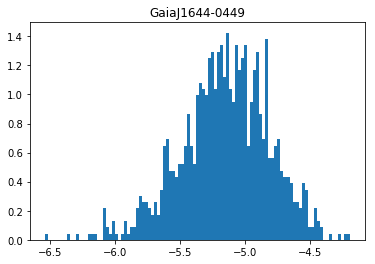

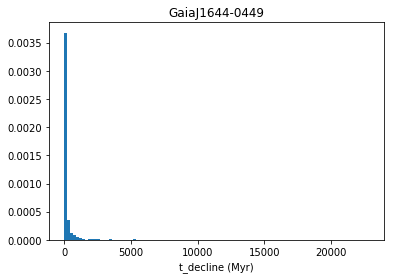

doing simultaneous decline
cross_extrap
4351.21972979 8.46204936162
4351.21972979 8.46204936162
4351.21972979 8.46204936162
4351.21972979 8.46204936162
SDSSJ1330+6435 mean log(Li/Ca) -5.25763331487 +/- 0.758202128019
SDSSJ1330+6435 median log(Li/Ca) -5.24878531996 up/down -4.56042970948 -5.91642335571
mean t_decline 2.01127797595 Myr


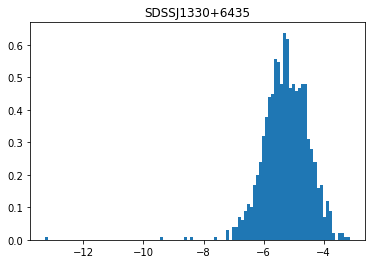

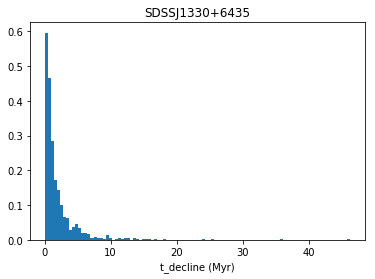

doing simultaneous decline
cross_extrap
4097.37952167 8.10349478821
4097.37952167 8.10349478821
4097.37952167 8.10349478821
4097.37952167 8.10349478821
WDJ2356-209 mean log(Li/Ca) -6.8814079033 +/- 0.266606668808
WDJ2356-209 median log(Li/Ca) -6.88731698911 up/down -6.62126121638 -7.14791334529
mean t_decline 11.5826811044 Myr


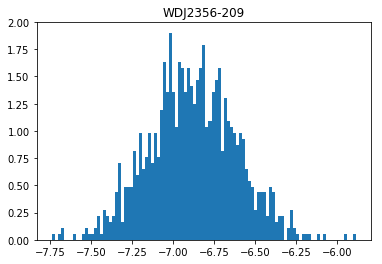

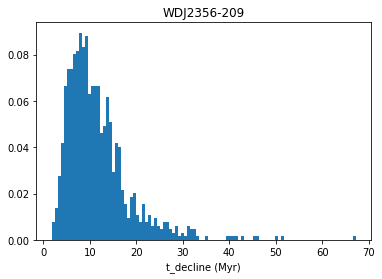

doing simultaneous decline
cross_extrap
3671.679719 7.56338350113
3671.679719 7.56338350113
3671.679719 7.56338350113
3671.679719 7.56338350113
GaiaJ1644-0449_nM mean log(Li/Ca) -5.14885702668 +/- 0.340131511745
GaiaJ1644-0449_nM median log(Li/Ca) -5.13056006964 up/down -4.83479971772 -5.4604272975
mean t_decline 229.51742156 Myr


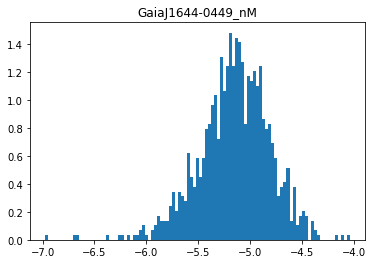

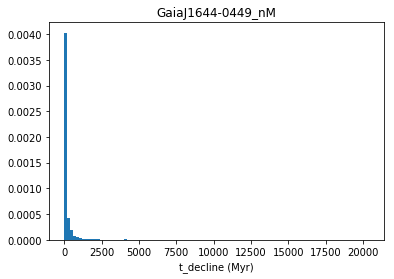

In [61]:
#Angra dos Reis from Tera et al. 1970
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na',-2.55 , int(1e3), plot_all=True)

doing simultaneous decline
cross_extrap
4314.89697212 7.7234817988
4314.89697212 7.7234817988
4314.89697212 7.7234817988
4314.89697212 7.7234817988
GaiaJ1644-0449 mean log(Li/Ca) -2.32565579533 +/- 0.290014905378
GaiaJ1644-0449 median log(Li/Ca) -2.3110909932 up/down -2.04359911931 -2.61086852271
mean t_decline 43.6086701904 Myr


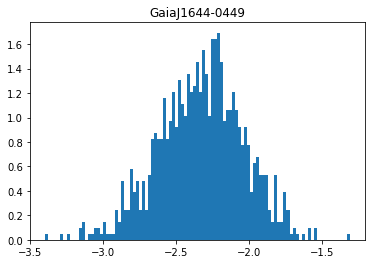

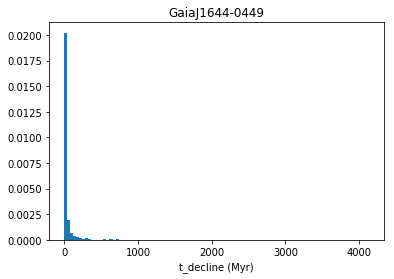

doing simultaneous decline
cross_extrap
4266.76714585 8.52259199007
4266.76714585 8.52259199007
4266.76714585 8.52259199007
4266.76714585 8.52259199007
SDSSJ1330+6435 mean log(Li/Ca) -2.41604897772 +/- 1.27149767524
SDSSJ1330+6435 median log(Li/Ca) -2.36199234611 up/down -1.72865103566 -3.03224656152
mean t_decline 0.498028450947 Myr


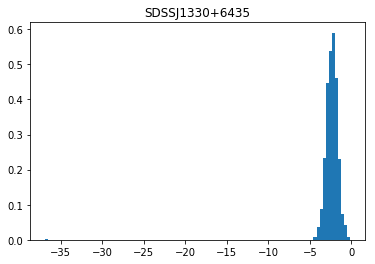

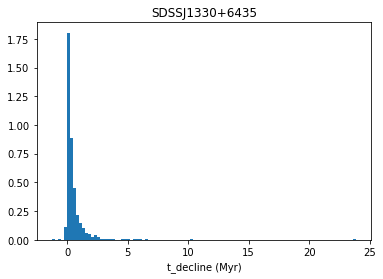

doing simultaneous decline
cross_extrap
3969.69746017 7.99131438194
3969.69746017 7.99131438194
3969.69746017 7.99131438194
3969.69746017 7.99131438194
WDJ2356-209 mean log(Li/Ca) -4.1700818635 +/- 0.267816913411
WDJ2356-209 median log(Li/Ca) -4.17567076254 up/down -3.89535989046 -4.42346606899
mean t_decline 4.85240618706 Myr


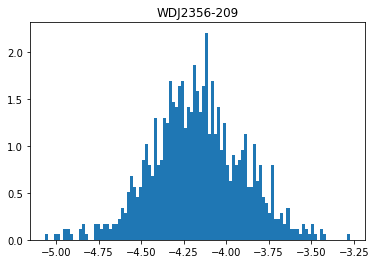

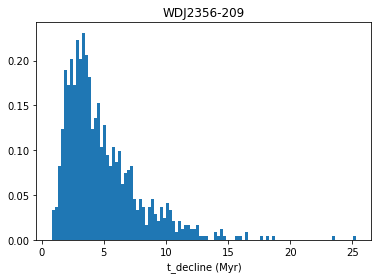

doing simultaneous decline
cross_extrap
4019.36140605 7.77186803021
4019.36140605 7.77186803021
4019.36140605 7.77186803021
4019.36140605 7.77186803021
GaiaJ1644-0449_nM mean log(Li/Ca) -2.32847173509 +/- 0.285368742067
GaiaJ1644-0449_nM median log(Li/Ca) -2.32730126521 up/down -2.05680721726 -2.61430156402
mean t_decline 45.5708395012 Myr


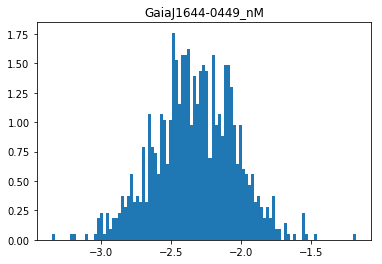

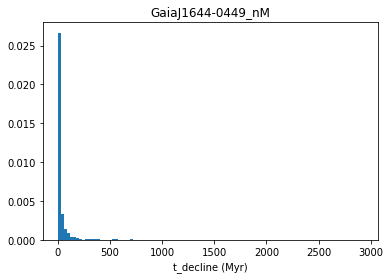

In [62]:
#Bulk Mars from Taylor 2013 (Table 4)
for row in wd_abund_table:
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na',-0.39, int(1e3), plot_all=True)

cross_extrap


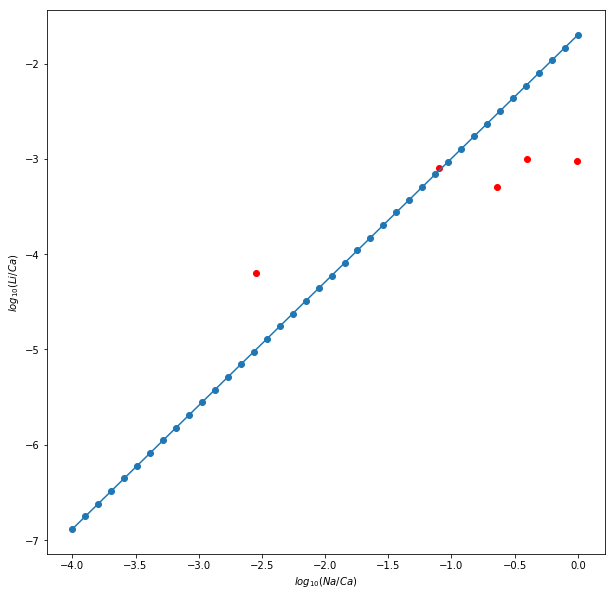

[-57562890.88521904   1475971.56115947   1475971.56115946
   1475971.56115945   1475971.56115947   1475971.56115946
   1475971.56115946   1475971.56115946   1475971.56115946
   1475971.56115946   1475971.56115946   1475971.56115947
   1475971.56115946   1475971.56115945   1475971.56115947
   1475971.56115946   1475971.56115946   1475971.56115946
   1475971.56115946   1475971.56115947   1475971.56115945
   1475971.56115947   1475971.56115947   1475971.56115946
   1475971.56115947   1475971.56115946   1475971.56115946
   1475971.56115947   1475971.56115946   1475971.56115947
   1475971.56115946   1475971.56115946   1475971.56115946
   1475971.56115946   1475971.56115946   1475971.56115946
   1475971.56115946   1475971.56115946   1475971.56115946
   1475971.56115946]
[ 57562890.88521904  56086919.32405958  54610947.76290011
  53134976.20174066  51659004.64058119  50183033.07942173
  48707061.51826227  47231089.95710281  45755118.39594334
  44279146.83478388  42803175.27362442  41327203.71

In [63]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
naca_line=np.linspace(-4, 0.0, 40)
t_decline, decline_LiCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['li/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'Li', 'Ca', 'Na', logg=j1644_row['logg'], cross_extrap=True)
plt.figure(figsize=(10,10))
plt.plot(naca_line, decline_LiCa, marker='o')
various_naca_list=[-1.1,-2.55, -0.4, -0.01, -0.64]
various_lica_list=[-3.1,-4.2, -3.0, -3.02, -3.3]
plt.scatter(various_naca_list,various_lica_list, color='r')
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(Li/Ca)$')
plt.show()
print(np.roll(t_decline,1)-t_decline)
print(t_decline)

# Messing with potassium instead of lithium


.

.

.

.

.

.

.

.

.

.

In [64]:
#from Mashonkina et al. 2019 and the other Mashonkina et al. 2019/2020 paper that included thin disk stars as well.
npoints=100
FeH_thick= np.linspace(-1.5,-0.4,npoints)
FeH_halo=np.linspace(-2.6,-1.2,npoints)
FeH_thin= np.linspace(-0.73, 0.24, npoints)

#from later Mashonkina et al. 2019/2020 and our by-eye approximation of the trend
def get_CaFe_thin(FeH):
    slope=(0-0.24)/(0+0.7)
    #print(slope)
    return slope*FeH

#from Takeda 2020 for FGK dwarfs over the range 
def get_KFe_thin(FeH):
    #uncertainties: slope +/- 0.022, intercept +/- 0.005
    return -0.129*FeH -0.008

def get_KCa_thin(FeH):
    return get_KFe_thin(FeH)-get_CaFe_thin(FeH)

print(get_KCa_thin(np.min(FeH_thin)))

def plot_objects_KCaNa(do_timetravel=True):
    #plt.axvline(x=-0.68, linestyle=":", color='k', label='SDSSJ1636+1619 Det. Limit')
    various_naca_list=[-1.1,-2.55, -0.4, -0.01, -0.64,0.0, 0.2, -0.74, -0.58, -0.47, -1.25,
                      -0.28,-0.49, -0.33,-0.5,
                       -0.06,-0.04,-0.04,
                       0.15,0.0,
                       -1.19,-1.14,-1.08,-1.18,
                       -0.38,
                       -0.35,-0.62,0.10,0.01,-0.02,
                       -1.56,-0.29
                      ]
    various_kca_list=[-2.3,-4.1, -1.7, -1.2,-1.86,-0.3, -1.5, -2.0, -1.67, -1.18, -1.98,
                     -1.53,-1.7,-1.63,-1.76,
                      -1.18,-1.15,-1.17,
                      -1.0,-1.15,
                      -1.87,-1.74,-1.47,-2.0,
                      -0.96,
                      -1.60,-1.80,-1.06,-1.35,-1.22,
                      -3.03,-2.62
                     ]
    name_list=['Eucrite', 'Angra dos Reis', 'Bulk Mars','CI Chondrite', 'Bulk Earth', "Earth\nContinental\nCrust","Halley\nDust/Ice",
              "Earth Primitive Mantle", "Shergotty", "Chassigny", "Nakhla",
              "CM","CV","CO","CK",
               "H","L","LL",
               "EH","EL",
               "lunar\nsoil","lunar\nbreccia","lunar\nHigh-K\nrock","lunar\nLow-K\nrock",
               "Knippa\nbasalt",
               "CR","CH","R","Acap.","K",
               "Binda","Johnstown"
              ]
    P67_vals=[1.17, -0.41, 0.54, 0.38]
    max_KCa_off_thin=get_KCa_thin(np.nanmin(FeH_thin))

    #plt.scatter(various_naca_list,various_kca_list, color='magenta', label='various bodies')
    index_val=0
    for naca, kca, name in zip(various_naca_list, various_kca_list, name_list):
        if index_val==0:
            plt.scatter(naca,kca, color='magenta', label='[Fe/H]_form=0')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b', label='[Fe/H]_form=-0.73')
            else:
                pass
        else:
            plt.scatter(naca,kca, color='magenta')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b')
            else:
                pass
        plt.text(naca, kca, name)
        index_val+=1
    
    
    plt.errorbar(P67_vals[0],P67_vals[1], xerr= P67_vals[2], yerr=P67_vals[3], color='magenta', marker='o')
    plt.errorbar(P67_vals[0],P67_vals[1]+max_KCa_off_thin, xerr= P67_vals[2], yerr=P67_vals[3], color='b', marker='o')
    plt.text(P67_vals[0], P67_vals[1], "67P Dust")
    return


-0.164115714286


Chris wants a more intuitive version of the dots on the K/Ca vs. Na/Ca plot, presumably one that conveys in even Myr intervals how much time would have had to pass for the declining phase to be where it is today.


I suppose it could also be good to have something indicating the mass of Calcium that would presumably also have been present at the time of the beginning of decline for each of those epochs if that were the case as well.


I think I should do this by first establishing the bound values of the Na/Ca range in Myr (to guarantee I don't overstep the timescales in my dot spacing) and then do the time steps or whatever. Or whatever fuck it.

In [65]:

def plot_wd_KCaNa(name, logg='default', teff='default', t_step=10, naca_min=-4.0, t_max=100, elements=["K","Ca","Na"]):
    """
    
    
    t_step=10, time in Myr of time-step for declining phase
    """
    string1= elements[0].lower()+'/'+elements[1].lower()
    string2=elements[2].lower()+'/'+elements[1].lower()
    times= np.arange(0, t_max+t_step, t_step)
    target_row=wd_abund_table.loc[name]
    if logg=='default':
        logg=target_row['logg']
    else:
        pass
    if teff=='default':
        teff= target_row['teff']
    else:
        pass
    #dp_el1el2, dp_el3el2= acorr.el1el2_DP_el3el2_ftimes(teff, target_row['k/ca'], target_row['na/ca'],times, 'K', "Ca", "Na", logg=logg)
    dp_el1el2, dp_el3el2= acorr.el1el2_DP_el3el2_ftimes(teff, target_row[string1], target_row[string2],times, elements[0], elements[1], elements[2], logg=logg)
    plt.plot(dp_el3el2, dp_el1el2, marker='o', label="teff="+str(teff)+'K,logg='+str(logg))
    slope=(dp_el1el2-np.roll(dp_el1el2,1))/(dp_el3el2-np.roll(dp_el3el2,1))
    print('Slope:', slope)
    return

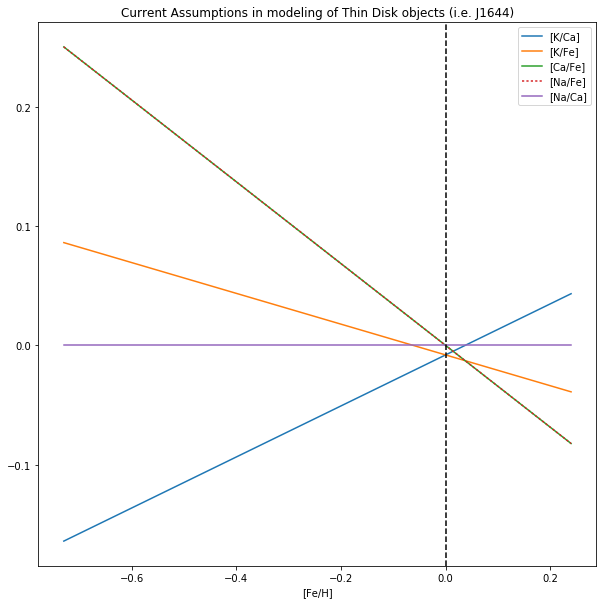

In [66]:
KCa_thin= get_KFe_thin(FeH_thin)-get_CaFe_thin(FeH_thin)
plt.figure(figsize=(10,10))
plt.plot(FeH_thin, KCa_thin, label='[K/Ca]')
plt.plot(FeH_thin, get_KFe_thin(FeH_thin), label='[K/Fe]')
plt.plot(FeH_thin, get_CaFe_thin(FeH_thin), label='[Ca/Fe]')
plt.plot(FeH_thin, get_CaFe_thin(FeH_thin), label='[Na/Fe]', linestyle=':')
plt.plot(FeH_thin, FeH_thin*0, label='[Na/Ca]')
plt.title('Current Assumptions in modeling of Thin Disk objects (i.e. J1644)')
plt.xlabel('[Fe/H]')
#plt.ylabel('[K/Ca]')
plt.axvline(x=0, color='k', linestyle='--')
#plt.axhline(y=0, color='k', linestyle='--')
plt.legend()
plt.show()

-10.94
doing simultaneous decline
cross_extrap
4037.18924395 7.93633126077
4037.18924395 7.93633126077
4037.18924395 7.93633126077
4037.18924395 7.93633126077
GaiaJ1644-0449 mean log(K/Ca) -1.2840110348 +/- 0.220384723076
GaiaJ1644-0449 median log(K/Ca) -1.27706426648 up/down -1.06668244965 -1.4932098906
mean t_decline 89.0449429691 Myr


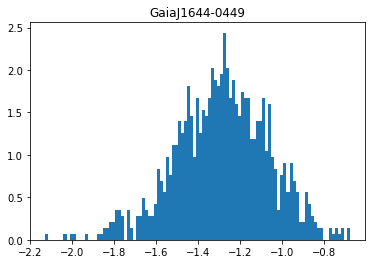

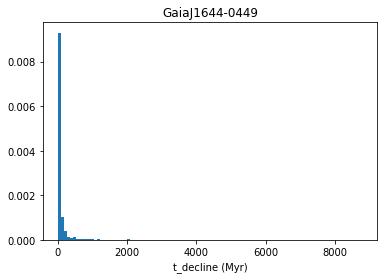

-9.1
doing simultaneous decline
cross_extrap
4326.45725423 8.16971733488
4326.45725423 8.16971733488
4326.45725423 8.16971733488
4326.45725423 8.16971733488
SDSSJ1330+6435 mean log(K/Ca) 0.0816753573759 +/- 0.326932520266
SDSSJ1330+6435 median log(K/Ca) 0.0817606701074 up/down 0.415533344908 -0.249824685675
mean t_decline 0.960591567631 Myr


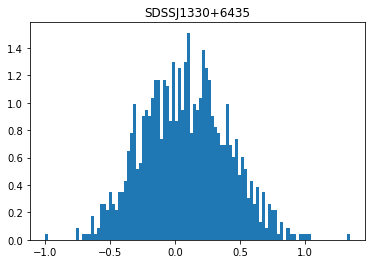

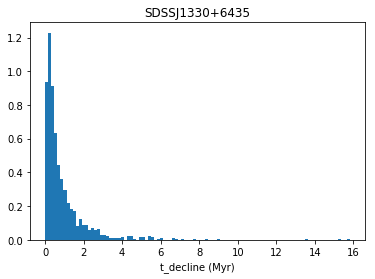

-10.35
doing simultaneous decline
cross_extrap
3954.38650207 8.00298222115
3954.38650207 8.00298222115
3954.38650207 8.00298222115
3954.38650207 8.00298222115
WDJ2356-209 mean log(K/Ca) -0.545763634178 +/- 0.115920626751
WDJ2356-209 median log(K/Ca) -0.543283911643 up/down -0.431907372264 -0.657242618792
mean t_decline 7.09334113479 Myr


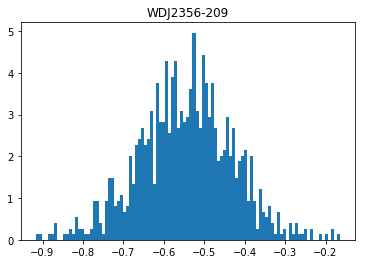

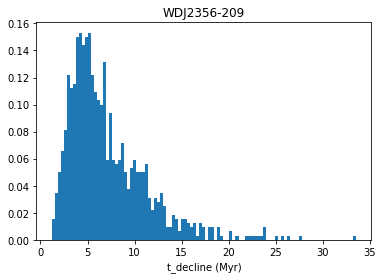

-10.94
doing simultaneous decline
cross_extrap
3639.030232 7.92833134176
3639.030232 7.92833134176
3639.030232 7.92833134176
3639.030232 7.92833134176
GaiaJ1644-0449_nM mean log(K/Ca) -1.29242253111 +/- 0.217617996561
GaiaJ1644-0449_nM median log(K/Ca) -1.28883685555 up/down -1.09198452777 -1.50717119914
mean t_decline 98.8880561738 Myr


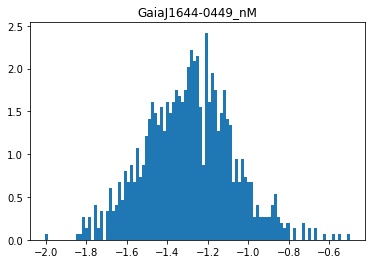

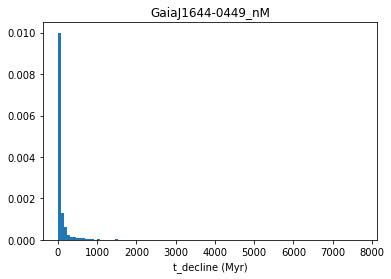

In [67]:
for row in wd_abund_table:
    print(row['k/he'])
    acorr.easy_dist_decline(row, 'K', 'Ca','Na', -1.1, int(1e3), plot_all=True)

-10.94
doing simultaneous decline
cross_extrap
3467.65138978 7.76041670079
3467.65138978 7.76041670079
3467.65138978 7.76041670079
3467.65138978 7.76041670079
GaiaJ1644-0449 mean log(K/Ca) -1.42774962539 +/- 0.191447645398
GaiaJ1644-0449 median log(K/Ca) -1.42689725607 up/down -1.23291971932 -1.6167117913
mean t_decline 5.040796448 Myr


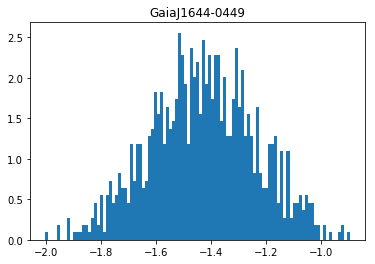

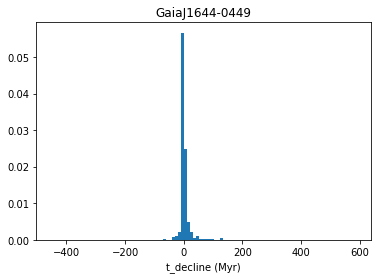

-9.1
doing simultaneous decline
cross_extrap
4366.85549267 8.01283387397
4366.85549267 8.01283387397
4366.85549267 8.01283387397
4366.85549267 8.01283387397
SDSSJ1330+6435 mean log(K/Ca) -0.219952978649 +/- 0.321761549219
SDSSJ1330+6435 median log(K/Ca) -0.220796004062 up/down 0.0955091524223 -0.54114217887
mean t_decline 0.216718096484 Myr


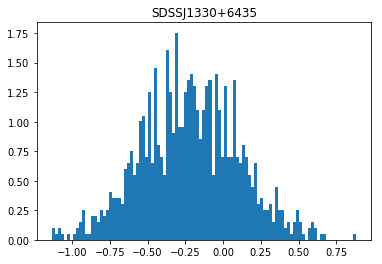

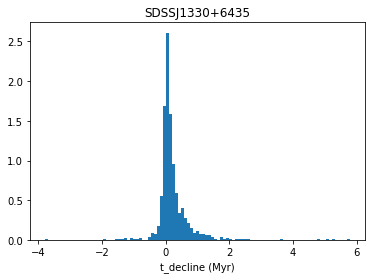

-10.35
doing simultaneous decline
cross_extrap
3960.33653024 7.94500959528
3960.33653024 7.94500959528
3960.33653024 7.94500959528
3960.33653024 7.94500959528
WDJ2356-209 mean log(K/Ca) -0.745005912596 +/- 0.109834503086
WDJ2356-209 median log(K/Ca) -0.744923901095 up/down -0.637357626082 -0.859029155717
mean t_decline 3.63319507669 Myr


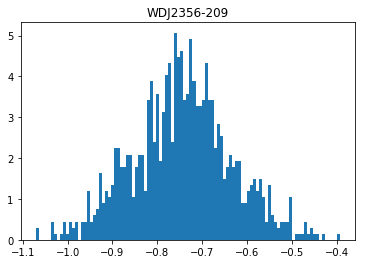

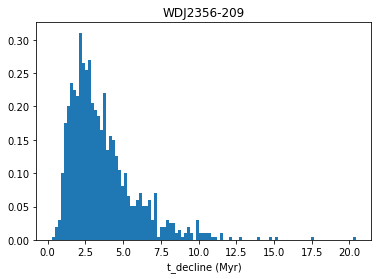

-10.94
doing simultaneous decline
cross_extrap
4080.97825113 7.75228535865
4080.97825113 7.75228535865
4080.97825113 7.75228535865
4080.97825113 7.75228535865
GaiaJ1644-0449_nM mean log(K/Ca) -1.41601903648 +/- 0.197288601021
GaiaJ1644-0449_nM median log(K/Ca) -1.41801220425 up/down -1.21556713182 -1.60866140548
mean t_decline 6.15644490957 Myr


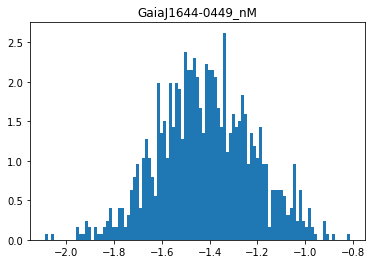

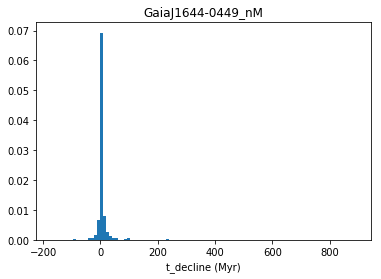

In [68]:
for row in wd_abund_table:
    print(row['k/he'])
    acorr.easy_dist_decline(row, 'K', 'Ca','Na',-0.01, int(1e3), plot_all=True)

-10.94
doing simultaneous decline
cross_extrap
3910.91235504 7.54014425326
3910.91235504 7.54014425326
3910.91235504 7.54014425326
3910.91235504 7.54014425326
GaiaJ1644-0449 mean log(K/Ca) -1.11769702389 +/- 0.286187641092
GaiaJ1644-0449 median log(K/Ca) -1.1319787276 up/down -0.84104814653 -1.38231792285
mean t_decline 261.987155928 Myr


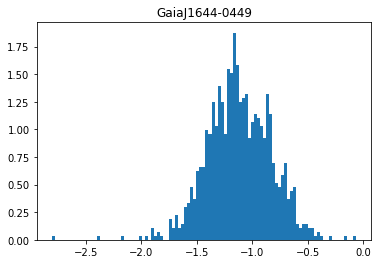

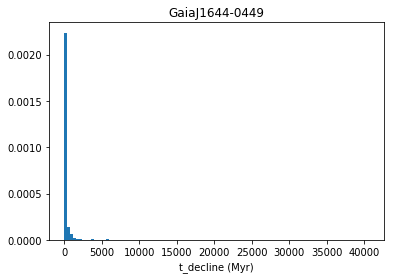

-9.1
doing simultaneous decline
cross_extrap
4172.21797764 8.20048124866
4172.21797764 8.20048124866
4172.21797764 8.20048124866
4172.21797764 8.20048124866
SDSSJ1330+6435 mean log(K/Ca) 0.481621144135 +/- 0.373829436946
SDSSJ1330+6435 median log(K/Ca) 0.484724905066 up/down 0.848848873802 0.0984163542377
mean t_decline 2.22389846567 Myr


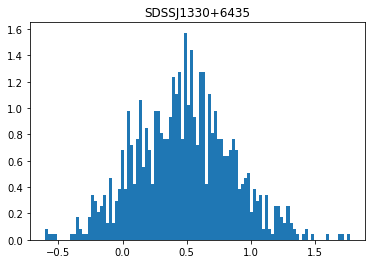

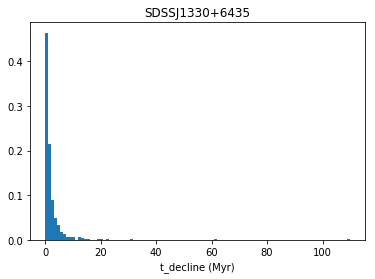

-10.35
doing simultaneous decline
cross_extrap
3939.1760542 7.97386394966
3939.1760542 7.97386394966
3939.1760542 7.97386394966
3939.1760542 7.97386394966
WDJ2356-209 mean log(K/Ca) -0.290429682684 +/- 0.137104522204
WDJ2356-209 median log(K/Ca) -0.291935076156 up/down -0.158651929503 -0.426675033728
mean t_decline 11.8147607208 Myr


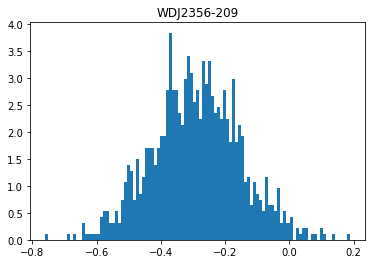

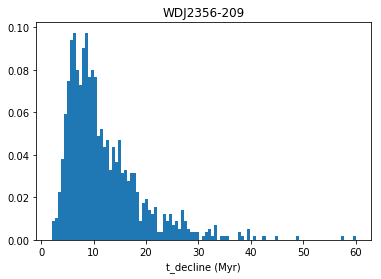

-10.94
doing simultaneous decline
cross_extrap
3649.22807918 7.67684996992
3649.22807918 7.67684996992
3649.22807918 7.67684996992
3649.22807918 7.67684996992
GaiaJ1644-0449_nM mean log(K/Ca) -1.11365096557 +/- 0.289763892864
GaiaJ1644-0449_nM median log(K/Ca) -1.11268579506 up/down -0.829243288994 -1.3824844481
mean t_decline 297.203563762 Myr


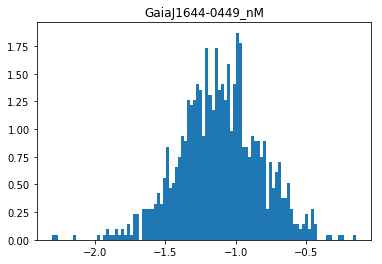

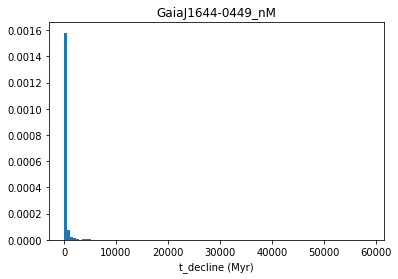

In [69]:
for row in wd_abund_table:
    print(row['k/he'])
    acorr.easy_dist_decline(row, 'K', 'Ca','Na', -2.55, int(1e3), plot_all=True)

In [70]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
naca_line=np.linspace(-4, 0.0, 40)
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=j1644_row['logg'], cross_extrap=True)

cross_extrap


cross_extrap
cross_extrap
cross_extrap


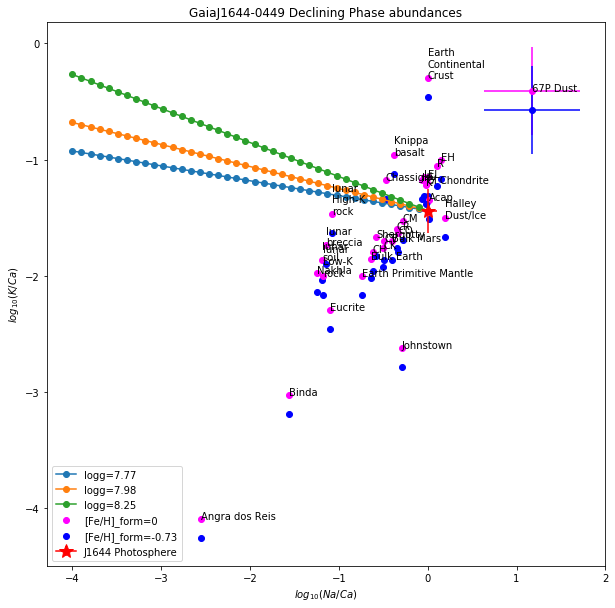

[-1403874.57375647    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247
    35996.78394247    35996.78394247    35996.78394247    35996.78394247]
[ 1403874.57375647  1367877.789814    1331881.00587152  1295884.22192905
  1259887.43798658  1223890.6540441   1187893.87010163  1151897.08615916
  1115900.30221668  1079903.51827421  1043906.73433173  1007909.95038926
   971913.16644679   935916.38250431   899919.5985

In [71]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
plt.figure(figsize=(10,10))
naca_line=np.linspace(-4, 0.0, 40)
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='J1644 Photosphere', marker='*', markersize=14, color='r')
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=j1644_row['logg'], cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o', label='logg='+str(j1644_row['logg']))

t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=7.98, cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o',label='logg=7.98' )
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=8.25, cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o',label='logg=8.25' )
"""
various_naca_list=[-1.1,-2.55, -0.4, -0.01, -0.64,0.0, 0.2]
various_kca_list=[-2.3,-4.1, -1.7, -1.2,-1.86,-0.3, -1.5]
name_list=['Eucrite', 'Angra dos Reis', 'Bulk Mars','CI Chondrite', 'Bulk Earth', "Earth\nContinental\nCrust","Halley\nDust/Ice"]

max_KCa_off_thin=get_KCa_thin(np.nanmin(FeH_thin))

#plt.scatter(various_naca_list,various_kca_list, color='magenta', label='various bodies')
index_val=0
for naca, kca, name in zip(various_naca_list, various_kca_list, name_list):
    if index_val==0:
        plt.scatter(naca,kca, color='magenta', label='[Fe/H]_form=0')
        plt.scatter(naca,kca+max_KCa_off_thin, color='b', label='[Fe/H]_form=-0.73')
    else:
        plt.scatter(naca,kca, color='magenta')
        plt.scatter(naca,kca+max_KCa_off_thin, color='b')
    plt.text(naca, kca, name)
    index_val+=1
"""
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title('GaiaJ1644-0449 Declining Phase abundances')
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()
print(np.roll(t_decline,1)-t_decline)
print(t_decline)

K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
K log tau 5.79103486363
Ca log tau 5.83911717733
Na log tau 6.25580244312
Slope: [-0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017
 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017
 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017
 -0.18978017 -0.18978017 -0.18978017]
K log tau 4.89374710344
Ca log tau 4.96463097165
Na log tau 5.36776286654
Slope: [-0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265
 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265
 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265
 -0.29316265 -0.29316265

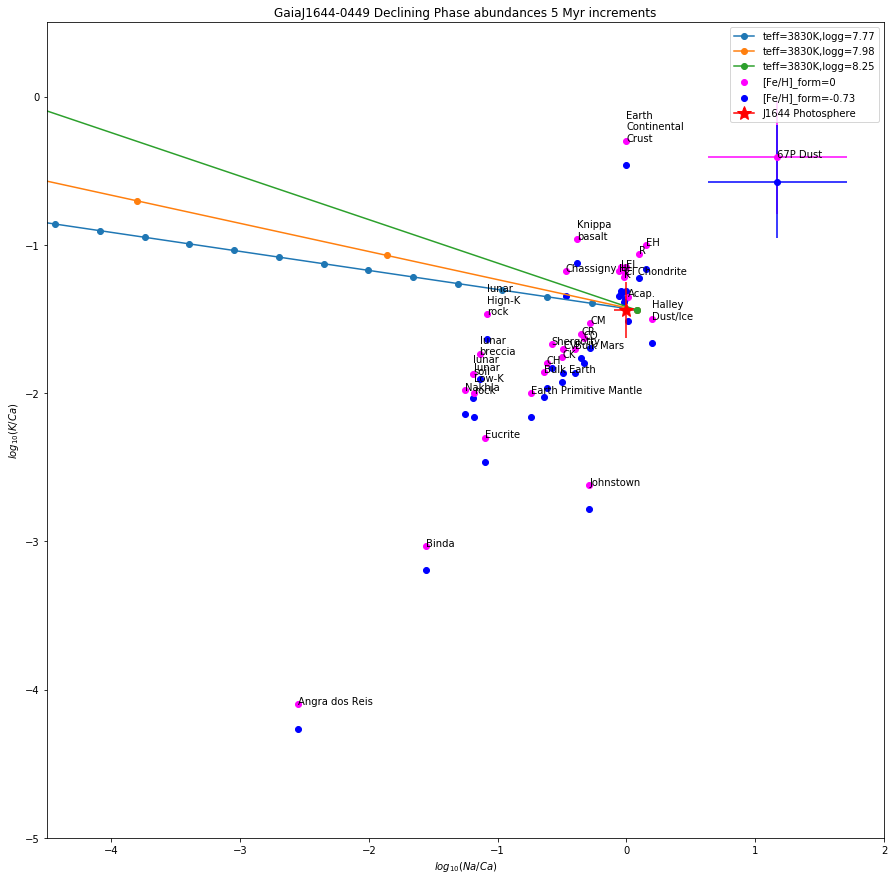

In [72]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
plt.figure(figsize=(15,15))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='J1644 Photosphere', marker='*', markersize=14, color='r')
plot_wd_KCaNa("GaiaJ1644-0449", logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", logg=7.98, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", logg=8.25, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title('GaiaJ1644-0449 Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()

Let's zoom in on the region of interest in that...

K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
K log tau 5.79103486363
Ca log tau 5.83911717733
Na log tau 6.25580244312
Slope: [-0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017
 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017
 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017 -0.18978017
 -0.18978017 -0.18978017 -0.18978017]
K log tau 4.89374710344
Ca log tau 4.96463097165
Na log tau 5.36776286654
Slope: [-0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265
 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265
 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265 -0.29316265
 -0.29316265 -0.29316265

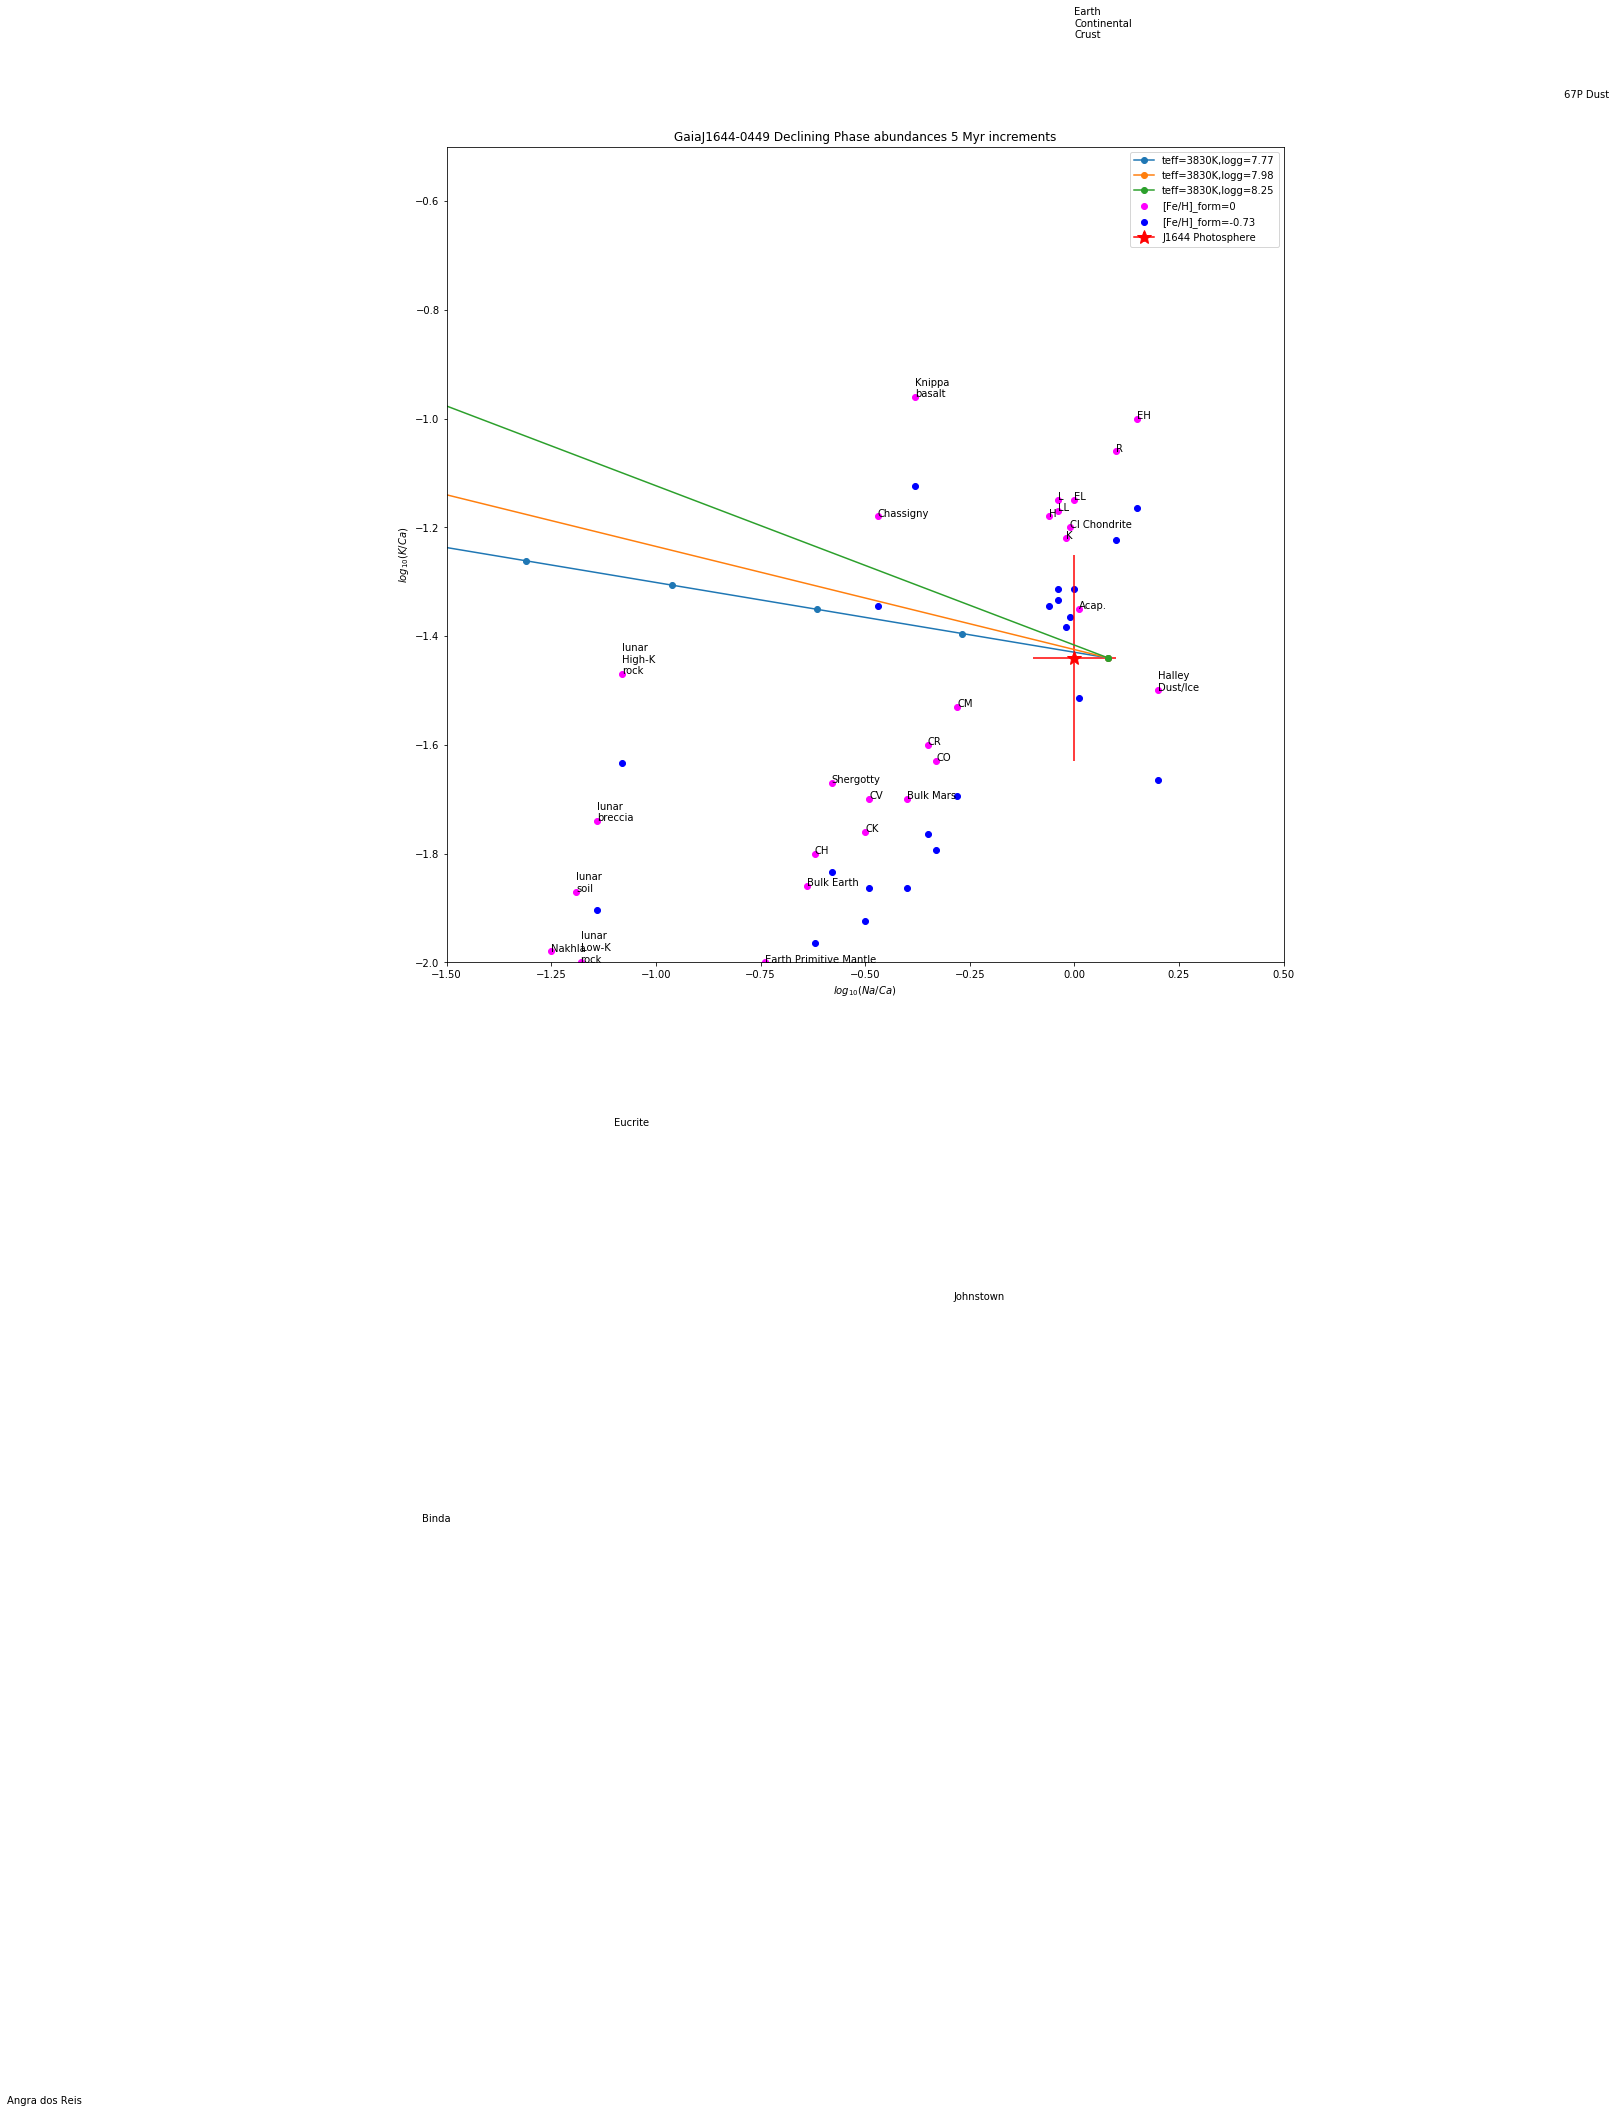

In [73]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
plt.figure(figsize=(15,15))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='J1644 Photosphere', marker='*', markersize=14, color='r')
plot_wd_KCaNa("GaiaJ1644-0449", logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", logg=7.98, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", logg=8.25, t_step=t_step, naca_min=-4.0, t_max=t_max)

plot_objects_KCaNa()
plt.xlim(-1.5,0.5)
plt.ylim(-2,-0.5)
plt.legend(loc='best')
plt.title('GaiaJ1644-0449 Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()

K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467]
K log tau 6.51866982991
Ca log tau 6.54673691222
Na log tau 6.89325156931
Slope: [-0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587
 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587]
K log tau 6.50435703835
Ca log tau 6.537285913
Na log tau 6.90440420686
Slope: [-0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244
 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244]


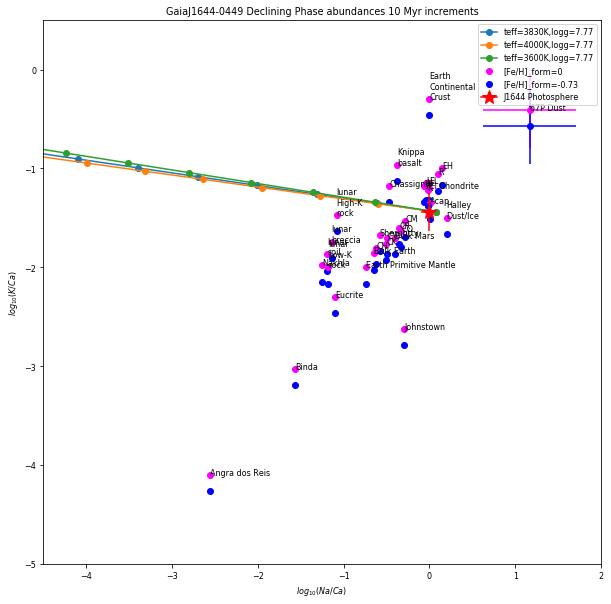

In [74]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
plt.rc('font',size=8)
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=10
t_max=100
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='J1644 Photosphere', marker='*', markersize=14, color='r')
plot_wd_KCaNa("GaiaJ1644-0449", teff='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=4000, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=3600, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title('GaiaJ1644-0449 Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()


K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
K log tau 6.51866982991
Ca log tau 6.54673691222
Na log tau 6.89325156931
Slope: [-0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587
 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587
 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587
 -0.12144587 -0.12144587 -0.12144587]
K log tau 6.50435703835
Ca log tau 6.537285913
Na log tau 6.90440420686
Slope: [-0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244
 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244
 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244
 -0.13805244 -0.13805244 -

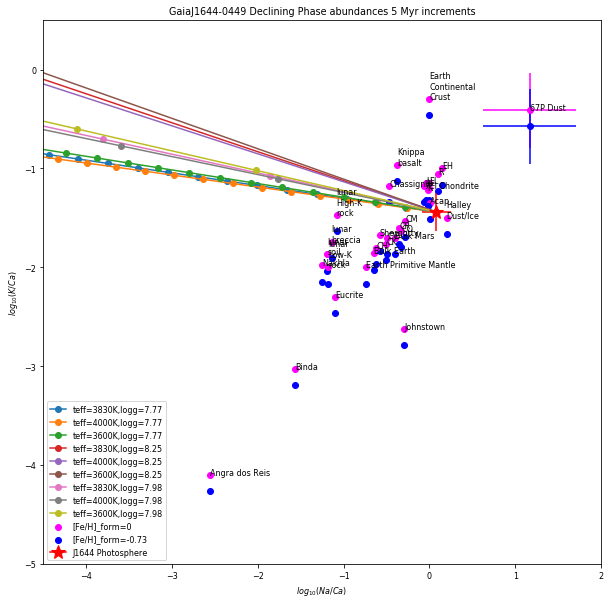

In [75]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['k/ca_err'], label='J1644 Photosphere', marker='*', markersize=14, color='r')
plot_wd_KCaNa("GaiaJ1644-0449", teff='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=4000, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=3600, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff='default', logg=8.25, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=4000, logg=8.25, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=3600, logg=8.25, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff='default', logg=7.98, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=4000, logg=7.98, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=3600, logg=7.98, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title('GaiaJ1644-0449 Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()


cross_extrap
cross_extrap
cross_extrap


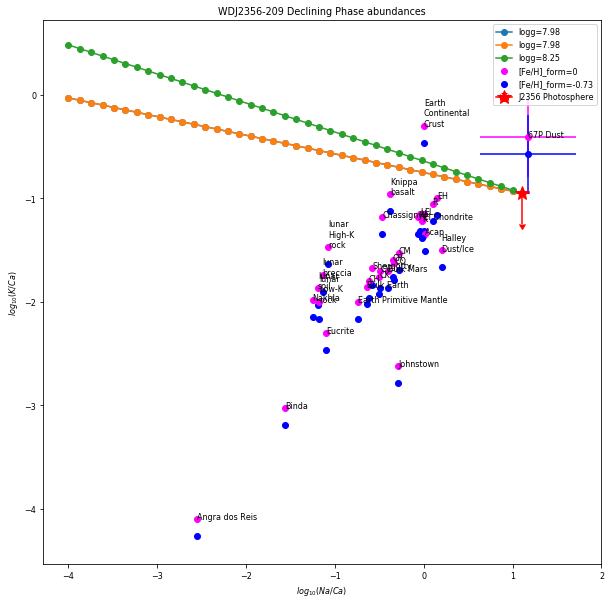

[-1932289.65405978    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564
    49545.88856564    49545.88856564    49545.88856564    49545.88856564]
[ 1970935.44714097  1921389.55857534  1871843.6700097   1822297.78144407
  1772751.89287843  1723206.0043128   1673660.11574716  1624114.22718153
  1574568.33861589  1525022.45005026  1475476.56148462  1425930.67291898
  1376384.78435335  1326838.89578771  1277293.0072

In [76]:
j1644_row=wd_abund_table.loc['WDJ2356-209']
plt.figure(figsize=(10,10))
naca_line=np.linspace(-4, 1.0, 40)
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=0.3, uplims=True,label='J2356 Photosphere', marker='*', color='r', markersize=14)
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=j1644_row['logg'], cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o', label='logg='+str(j1644_row['logg']))

t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=7.98, cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o',label='logg=7.98' )
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=8.25, cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o',label='logg=8.25' )
plot_objects_KCaNa()


plt.legend(loc='best')
plt.title('WDJ2356-209 Declining Phase abundances')
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()
print(np.roll(t_decline,1)-t_decline)
print(t_decline)

K log tau 5.81500703073
Ca log tau 5.85997610257
Na log tau 6.26380115601
Slope: [-0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937]
K log tau 4.93267572928
Ca log tau 4.99979457974
Na log tau 5.39291474342
Slope: [-0.28063621 -0.28063621 -0.28063621 -0.28063621 -0.28063621 -0.28063621
 -0.28063621 -0.28063621 -0.28063621 -0.28063621 -0.28063621 -0.28063621
 -0.28063621 -0.28063621 -0.28063621 -0.28063621 -0.28063621 -0.28063621
 -0.28063621 -0.28063621 -0.28063621]
K log tau 5.83244946075
Ca log tau 5.87515330129
Na log tau 6.26962111334
Slope: [-0.17313647 -0.17313647 -0.17313647 -0.17313647 -0.17313647 -0.17313647
 -0.17313647 -0.17313647 -0.17313647 -0.17313647 -0.17313647 -0.17313647
 -0.17313647 -0.17313647 -0.17313647 -0.17313647 -0.17313647 -0.17313647
 -0.17313647 -0.17313647

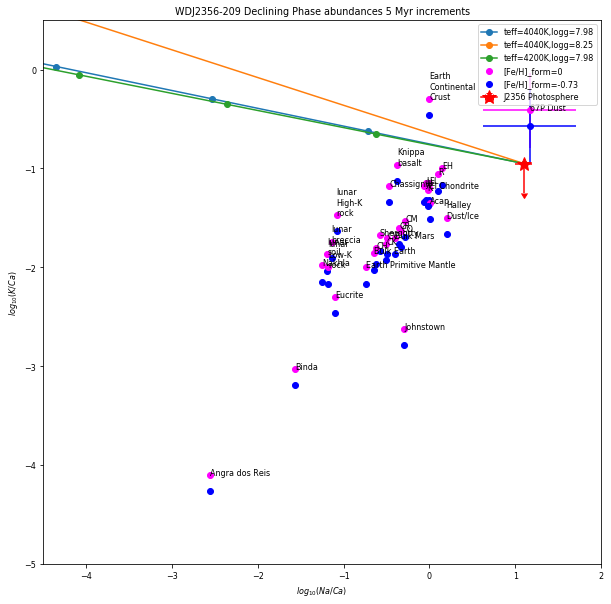

In [77]:
wd_name='WDJ2356-209'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=0.3, uplims=True,label='J2356 Photosphere', marker='*', color='r', markersize=14)

plot_wd_KCaNa(wd_name, logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa(wd_name, logg=8.25, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()



In [78]:
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], j1644_row['k/ca'], j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=j1644_row['logg'], cross_extrap=True)
plt.plot(naca_line, decline_KCa, marker='o', label='logg='+str(j1644_row['logg']))

cross_extrap


cross_extrap
cross_extrap


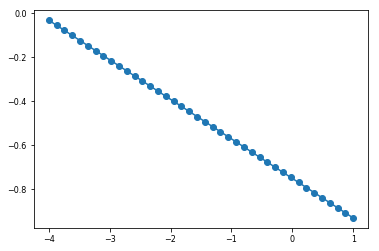

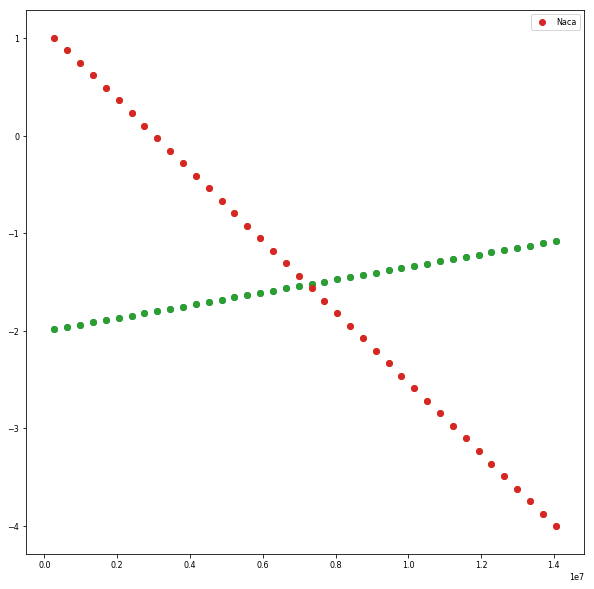

In [79]:
plt.figure(figsize=(10,10))
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], -2.0, j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=j1644_row['logg'], cross_extrap=True)
plt.scatter(t_decline, decline_KCa)
plt.scatter(t_decline, naca_line)
t_decline, decline_KCa=acorr.el1el2_DP_el3el2(j1644_row['teff'], -2.0, j1644_row['na/he']-j1644_row['ca/he'], naca_line, 'K', 'Ca', 'Na', logg=7.98, cross_extrap=True)
plt.scatter(t_decline, decline_KCa)
plt.scatter(t_decline, naca_line, label='Naca')
#plt.xscale('log')
plt.legend()
plt.show()

In [80]:
print((1*u.M_sun).to(u.kg))

1.98847541534e+30 kg


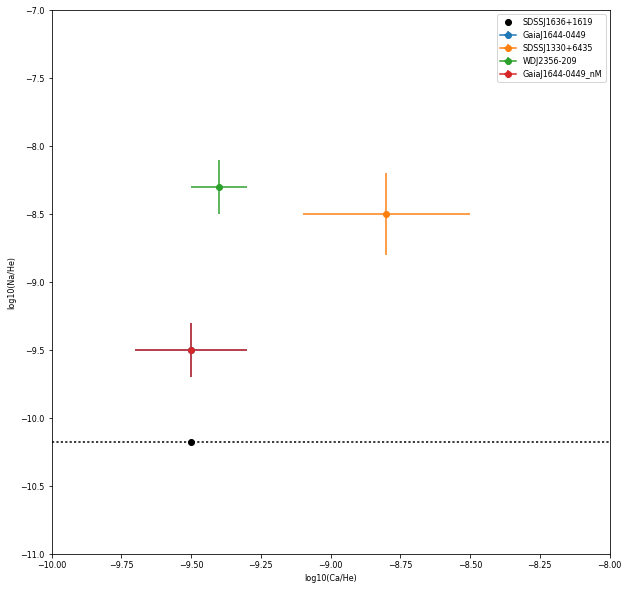

In [81]:
plt.figure(figsize=(10,10))
for row in wd_abund_table:
    plt.errorbar(row['ca/he'], row['na/he'], xerr=row['ca/he_err'], yerr=row['na/he_err'], marker='o', label=row['name'])
#
plt.scatter(-9.5, -10.18, label='SDSSJ1636+1619', color='k', marker='o')
plt.axhline(y=-10.18, linestyle=':', color='k')
plt.xlabel("log10(Ca/He)")
plt.ylabel('log10(Na/He)')
plt.xlim(-10, -8)
plt.ylim(-11, -7)
plt.legend()
plt.show()

4274.07863316 7.84284098796
GaiaJ1644-0449 median t =  10.5206841487 Myr


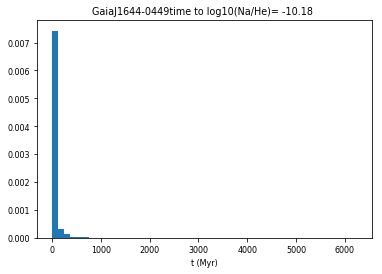

4324.8880796 8.25211601851
SDSSJ1330+6435 median t =  0.979573819444 Myr


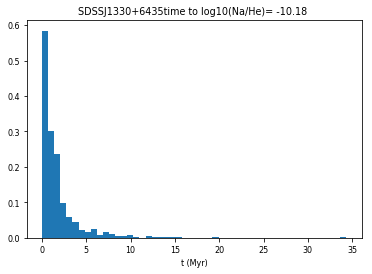

3799.31676665 8.00005799969
WDJ2356-209 median t =  7.87240491452 Myr


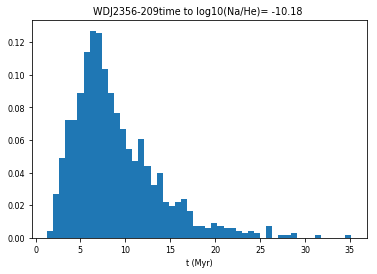

3727.18574573 8.15151285008
GaiaJ1644-0449_nM median t =  11.2099721632 Myr


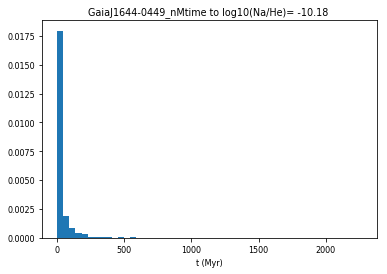

In [82]:
n_points=int(1e3)
for row in wd_abund_table:
    teff_array=np.random.normal(loc=row['teff'], scale=row['teff_err'], size=n_points)
    logg_array=np.random.normal(loc=row['logg'], scale=row['logg_err'], size=n_points)
    nahe_array=np.random.normal(loc=row['na/he'], scale=row['na/he_err'], size=n_points)
    time_required=acorr.get_t_relHe_fwd('Na', teff_array, nahe_array, np.ones(teff_array.shape)*-10.18, logg=logg_array, cross_extrap=True)*1e-6
    #time_required=acorr.get_t_relHe_fwd('Na', row['teff'], row['na/he'], -10.18, logg=row['logg'], cross_extrap=True)*1e-6
    print(row['name'], 'median t = ',np.median(time_required), 'Myr')
    plt.hist(time_required, bins=50, normed=True)
    plt.title(row['name']+"time to log10(Na/He)= -10.18 ")
    plt.xlabel('t (Myr)')
    plt.show()

-9.5
doing simultaneous decline
cross_extrap
3906.10460754 7.46483060595
3906.10460754 7.46483060595
3906.10460754 7.46483060595
3906.10460754 7.46483060595
GaiaJ1644-0449 mean log(Li/Ca) -2.42492564286 +/- 0.294465017597
GaiaJ1644-0449 median log(Li/Ca) -2.41136349265 up/down -2.14413868104 -2.725014116
mean t_decline 47.542064894 Myr


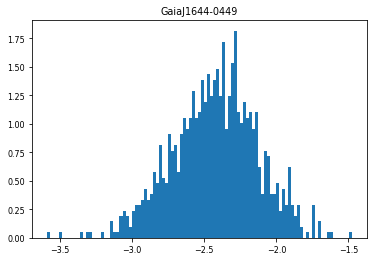

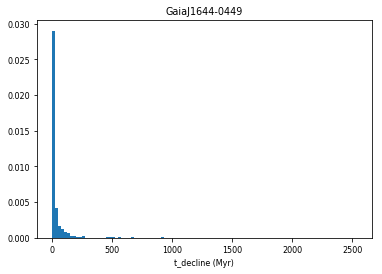

-8.5
doing simultaneous decline
cross_extrap
4159.47196787 8.23024613831
4159.47196787 8.23024613831
4159.47196787 8.23024613831
4159.47196787 8.23024613831
SDSSJ1330+6435 mean log(Li/Ca) -2.50893463848 +/- 0.669111603464
SDSSJ1330+6435 median log(Li/Ca) -2.51466224383 up/down -1.84948714298 -3.14529887128
mean t_decline 0.538447413438 Myr


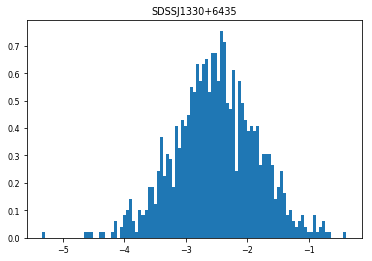

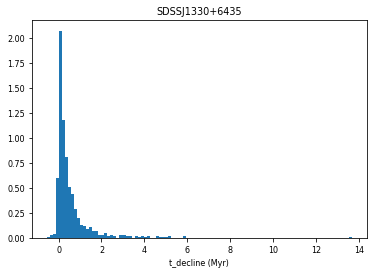

-8.3
doing simultaneous decline
cross_extrap
3848.802019 7.96214771043
3848.802019 7.96214771043
3848.802019 7.96214771043
3848.802019 7.96214771043
WDJ2356-209 mean log(Li/Ca) -4.27170486737 +/- 0.270759728731
WDJ2356-209 median log(Li/Ca) -4.26973855756 up/down -4.00887059057 -4.52539164099
mean t_decline 5.07824502444 Myr


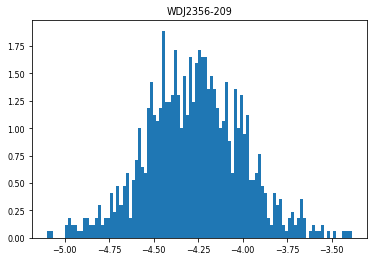

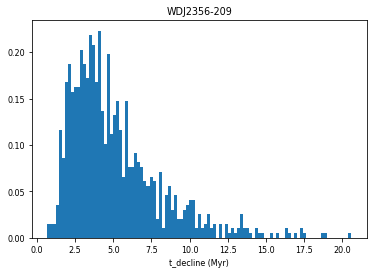

-9.5
doing simultaneous decline
cross_extrap
3428.89448804 7.82896770095
3428.89448804 7.82896770095
3428.89448804 7.82896770095
3428.89448804 7.82896770095
GaiaJ1644-0449_nM mean log(Li/Ca) -2.42094192091 +/- 0.294635089516
GaiaJ1644-0449_nM median log(Li/Ca) -2.4185038979 up/down -2.13007466592 -2.70519906681
mean t_decline 57.5261951435 Myr


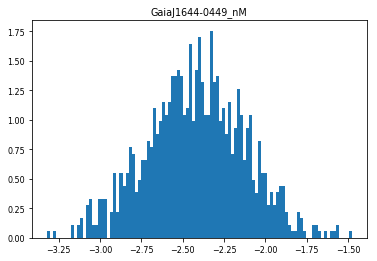

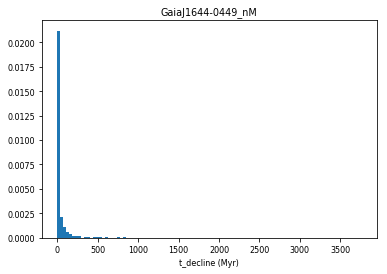

In [83]:
#Chassigny
for row in wd_abund_table:
    print(row['na/he'])
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -0.47, int(1e3), plot_all=True)

K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467]
K log tau 6.51866982991
Ca log tau 6.54673691222
Na log tau 6.89325156931
Slope: [-0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587
 -0.12144587 -0.12144587 -0.12144587 -0.12144587 -0.12144587]
K log tau 6.50435703835
Ca log tau 6.537285913
Na log tau 6.90440420686
Slope: [-0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244
 -0.13805244 -0.13805244 -0.13805244 -0.13805244 -0.13805244]
K log tau 6.59469132692
Ca log tau 6.59693530337
Na log tau 6.83401503265
Slope: [-0.01231422 -0.01231422 -0.01231422 -0.01231422 -0.01231422 -0.01231422
 -0.01231422 -0.01231422 -0.01231422 -0.01231422 -0.01231422]
K log tau 6.06185415773
Ca log tau 6.07476543505
Na log tau 6.34616581196
Slope: [-0.06493616 -0.06493616 -0.06493616 -0.06493616 -0.06493

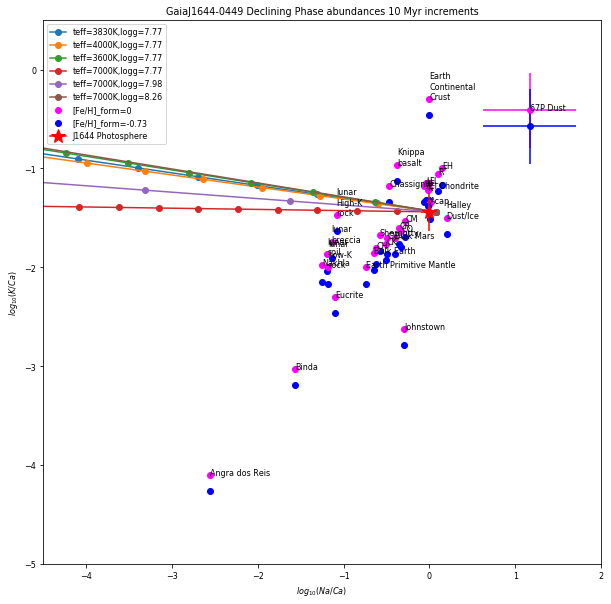

In [84]:
j1644_row=wd_abund_table.loc['GaiaJ1644-0449']
plt.rc('font',size=8)
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=10
t_max=100
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='J1644 Photosphere', marker='*', markersize=14, color='r')
plot_wd_KCaNa("GaiaJ1644-0449", teff='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=4000, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=3600, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=7000, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=7000, logg=7.98, t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa("GaiaJ1644-0449", teff=7000, logg=8.26, t_step=t_step, naca_min=-4.0, t_max=t_max)



plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title('GaiaJ1644-0449 Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()



3269.63377167 7.6145948466
GaiaJ1644-0449 median t =  11.875787605 Myr


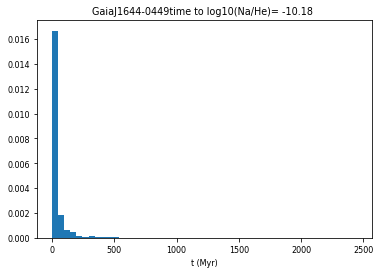

4115.80405184 8.45880864719
SDSSJ1330+6435 median t =  0.980132470172 Myr


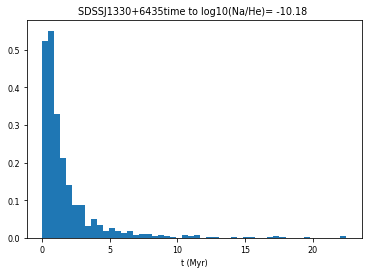

4080.17208827 7.92621712123
WDJ2356-209 median t =  8.1475390718 Myr


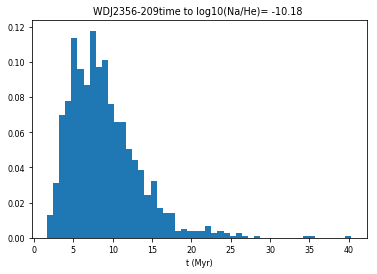

3841.87036783 7.66385670153
GaiaJ1644-0449_nM median t =  12.1513079129 Myr


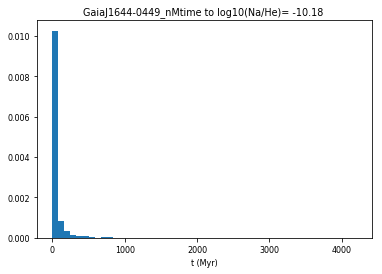

In [85]:
n_points=int(1e3)
for row in wd_abund_table:
    teff_array=np.random.normal(loc=row['teff'], scale=row['teff_err'], size=n_points)
    logg_array=np.random.normal(loc=row['logg'], scale=row['logg_err'], size=n_points)
    nahe_array=np.random.normal(loc=row['na/he'], scale=row['na/he_err'], size=n_points)
    time_required=acorr.get_t_relHe_fwd('Na', teff_array, nahe_array, np.ones(teff_array.shape)*-10.18, logg=logg_array, cross_extrap=True)*1e-6
    #time_required=acorr.get_t_relHe_fwd('Na', row['teff'], row['na/he'], -10.18, logg=row['logg'], cross_extrap=True)*1e-6
    print(row['name'], 'median t = ',np.median(time_required), 'Myr')
    plt.hist(time_required, bins=50, normed=True)
    plt.title(row['name']+"time to log10(Na/He)= -10.18 ")
    plt.xlabel('t (Myr)')
    plt.show()

-9.5
doing simultaneous decline
cross_extrap
4169.5161863 7.79185126478
4169.5161863 7.79185126478
4169.5161863 7.79185126478
4169.5161863 7.79185126478
GaiaJ1644-0449 mean log(Li/Ca) -3.23308152208 +/- 0.304432323336
GaiaJ1644-0449 median log(Li/Ca) -3.20589898742 up/down -2.9299732105 -3.54877688459
mean t_decline 79.8402321022 Myr


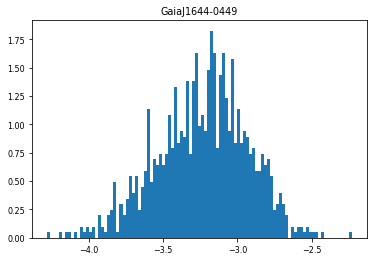

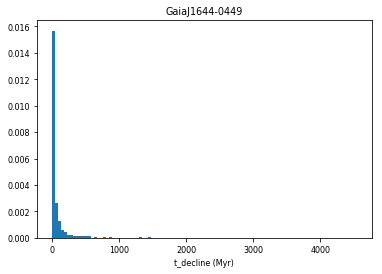

-8.5
doing simultaneous decline
cross_extrap
4094.780533 8.17067090301
4094.780533 8.17067090301
4094.780533 8.17067090301
4094.780533 8.17067090301
SDSSJ1330+6435 mean log(Li/Ca) -3.33580080996 +/- 0.763680179454
SDSSJ1330+6435 median log(Li/Ca) -3.31367151612 up/down -2.671553634 -3.99306144065
mean t_decline 1.0029892881 Myr


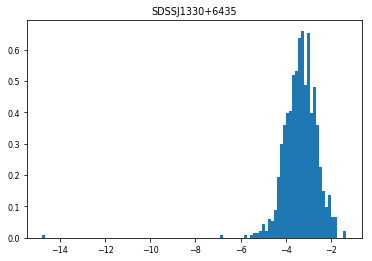

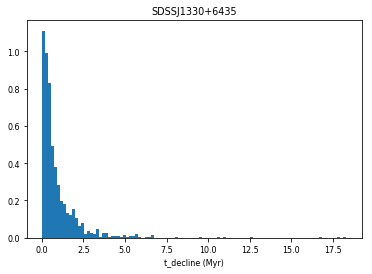

-8.3
doing simultaneous decline
cross_extrap
3860.17029158 8.04198689613
3860.17029158 8.04198689613
3860.17029158 8.04198689613
3860.17029158 8.04198689613
WDJ2356-209 mean log(Li/Ca) -5.0552264538 +/- 0.27192258809
WDJ2356-209 median log(Li/Ca) -5.05906020181 up/down -4.78247246303 -5.31964355037
mean t_decline 7.28948475858 Myr


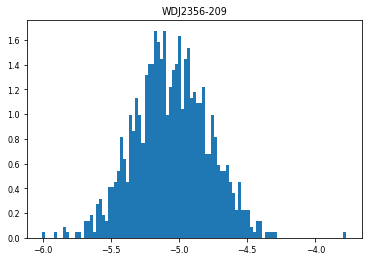

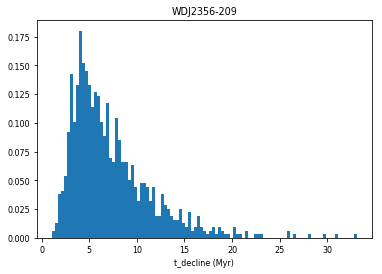

-9.5
doing simultaneous decline
cross_extrap
3871.26444473 7.86150007674
3871.26444473 7.86150007674
3871.26444473 7.86150007674
3871.26444473 7.86150007674
GaiaJ1644-0449_nM mean log(Li/Ca) -3.22771910209 +/- 0.31290546895
GaiaJ1644-0449_nM median log(Li/Ca) -3.23663894483 up/down -2.90734929668 -3.53906487518
mean t_decline 92.0021903493 Myr


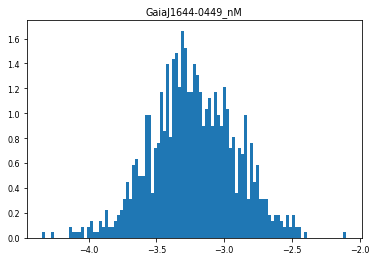

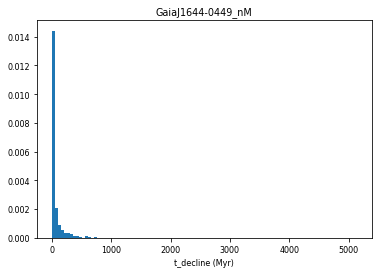

In [86]:
#High-K lunar rocks
for row in wd_abund_table:
    print(row['na/he'])
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -1.08, int(1e3), plot_all=True)

-9.5
doing simultaneous decline
cross_extrap
4134.74002118 7.96668795804
4134.74002118 7.96668795804
4134.74002118 7.96668795804
4134.74002118 7.96668795804
GaiaJ1644-0449 mean log(Li/Ca) -3.23645119436 +/- 0.302457257485
GaiaJ1644-0449 median log(Li/Ca) -3.23001512289 up/down -2.9347586343 -3.5429455173
mean t_decline 135.338693385 Myr


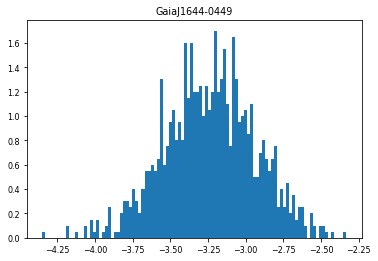

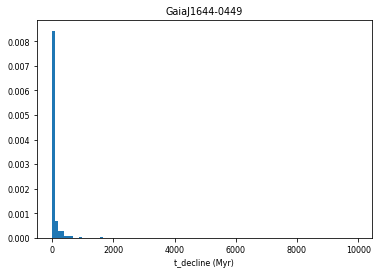

-8.5
doing simultaneous decline
cross_extrap
4503.7389238 8.28669342933
4503.7389238 8.28669342933
4503.7389238 8.28669342933
4503.7389238 8.28669342933
SDSSJ1330+6435 mean log(Li/Ca) -3.30914434864 +/- 0.721050097249
SDSSJ1330+6435 median log(Li/Ca) -3.29400645585 up/down -2.65162620699 -3.95475817552
mean t_decline 1.0605014516 Myr


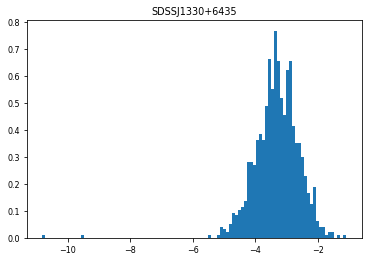

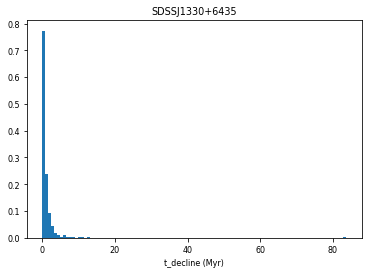

-8.3
doing simultaneous decline
cross_extrap
3942.02117724 7.96647211258
3942.02117724 7.96647211258
3942.02117724 7.96647211258
3942.02117724 7.96647211258
WDJ2356-209 mean log(Li/Ca) -5.0343371809 +/- 0.279889392223
WDJ2356-209 median log(Li/Ca) -5.03106781658 up/down -4.76286857211 -5.29203423473
mean t_decline 6.87755428575 Myr


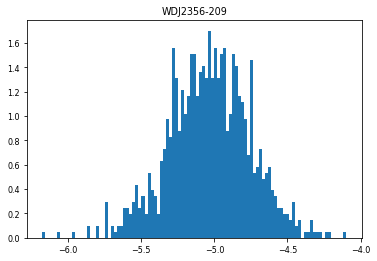

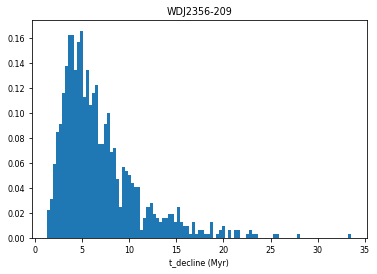

-9.5
doing simultaneous decline
cross_extrap
3791.36473725 7.48504243811
3791.36473725 7.48504243811
3791.36473725 7.48504243811
3791.36473725 7.48504243811
GaiaJ1644-0449_nM mean log(Li/Ca) -3.21096570283 +/- 0.304574437385
GaiaJ1644-0449_nM median log(Li/Ca) -3.20704832742 up/down -2.9092191035 -3.49964311595
mean t_decline 90.0894742176 Myr


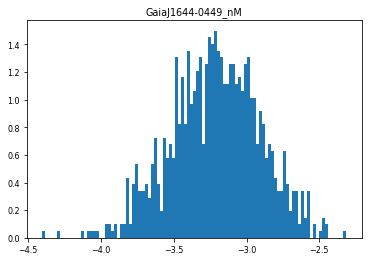

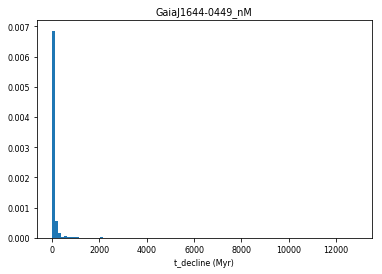

In [87]:
#median eucrite
for row in wd_abund_table:
    print(row['na/he'])
    acorr.easy_dist_decline(row, 'Li', 'Ca','Na', -1.07, int(1e3), plot_all=True)

K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603]
K log tau 5.26749152851
Ca log tau 5.32292608014
Na log tau 5.70845462082
Slope: [-0.23138377 -0.23138377 -0.23138377 -0.23138377 -0.23138377 -0.23138377
 -0.23138377 -0.23138377 -0.23138377 -0.23138377 -0.23138377 -0.23138377
 -0.23138377 -0.23138377 -0.23138377 -0.23138377 -0.23138377 -0.23138377
 -0.23138377 -0.23138377 -0.23138377]


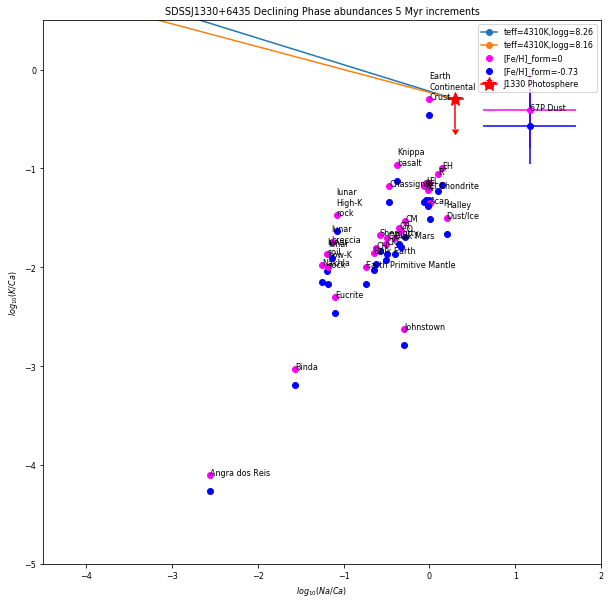

In [88]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=0.3, uplims=True,label='J1330 Photosphere', marker='*', color='r', markersize=14)

plot_wd_KCaNa(wd_name, logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
plot_wd_KCaNa(wd_name, logg=8.16, t_step=t_step, naca_min=-4.0, t_max=t_max)
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa()
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.show()




K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603]
K log tau 5.81500703073
Ca log tau 5.85997610257
Na log tau 6.26380115601
Slope: [-0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937

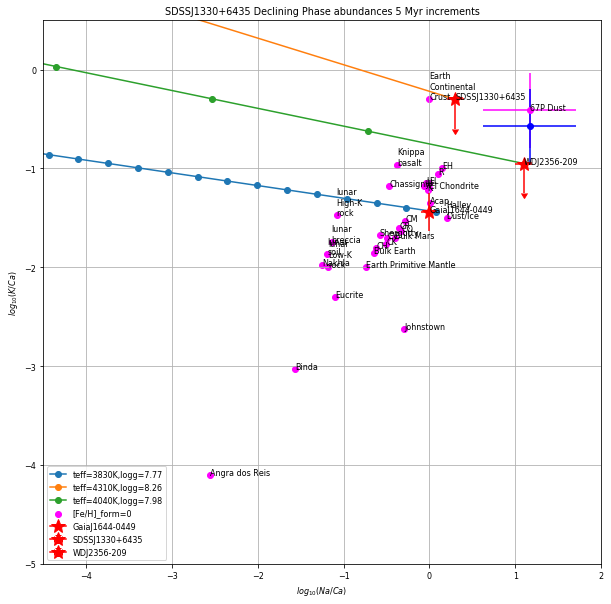

In [89]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
count=0
for j1644_row in wd_abund_table:
    if count==3:
        break
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker='*', markersize=14, color='r')
    else:
        plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=0.3, uplims=True,label=j1644_row['name'], marker='*', color='r', markersize=14)
    plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
    plt.text(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],j1644_row['name'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa(do_timetravel=False)
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.grid(True)
plt.show()





K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603]
K log tau 5.81500703073
Ca log tau 5.85997610257
Na log tau 6.26380115601
Slope: [-0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937

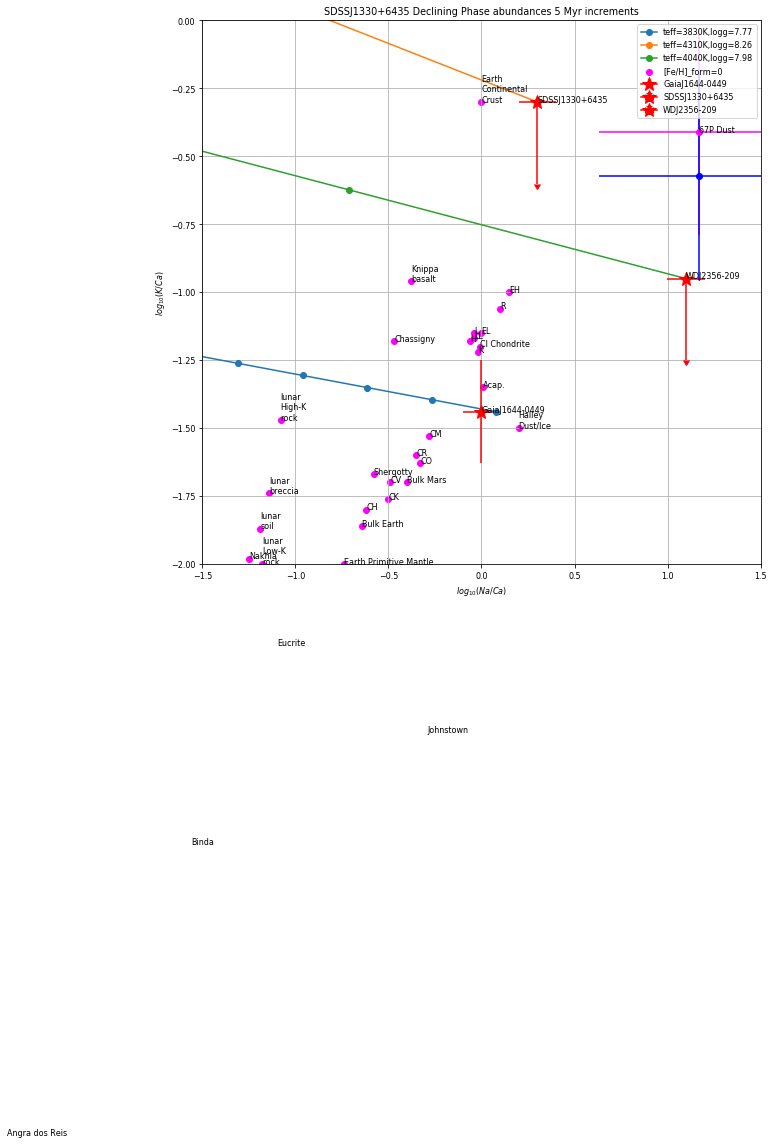

In [90]:

wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
count=0
for j1644_row in wd_abund_table:
    if count==3:
        break
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker='*', markersize=14, color='r')
    else:
        plt.errorbar(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],xerr=0.1,yerr=0.3, uplims=True,label=j1644_row['name'], marker='*', color='r', markersize=14)
    plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
    plt.text(j1644_row['na/he']-j1644_row['ca/he'],j1644_row['k/ca'],j1644_row['name'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-1.5,1.5)
plt.ylim(-2,0.0)
plot_objects_KCaNa(do_timetravel=False)
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.grid(True)
plt.show()


# 2020-03-05 Realized I had the wrong relative abundances in my damn table.

K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603]
K log tau 5.81500703073
Ca log tau 5.85997610257
Na log tau 6.26380115601
Slope: [-0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937 -0.18020937
 -0.18020937 -0.18020937

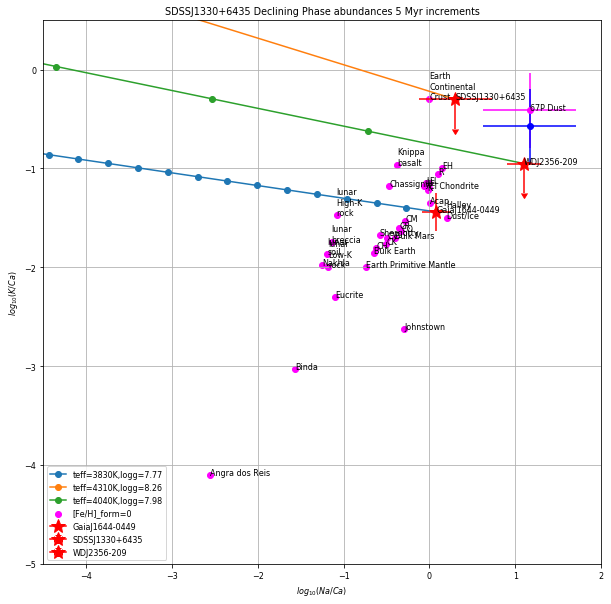

In [91]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
count=0
for j1644_row in wd_abund_table:
    if count==3:
        break
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker='*', markersize=14, color='r')
    else:
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker='*', color='r', markersize=14)
    plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
    plt.text(j1644_row['na/ca'],j1644_row['k/ca'],j1644_row['name'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
plot_objects_KCaNa(do_timetravel=False)
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.grid(True)
plt.show()








 GaiaJ1644-0449
K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467]
Li log tau 7.10157493218
Ca log tau 6.54284121453
Na log tau 6.89784868157


 SDSSJ1330+6435
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603]
Li log tau 5.62590159137
Ca log tau 5.01124238684
Na log tau 5.39172426907


 WDJ2356-209
K log tau 5.81500703073
Ca log tau 5.85997610257
Na log tau 6.26380115601
Slope: [-0.18020937 -0.18020937 -0.18020937 -0.18

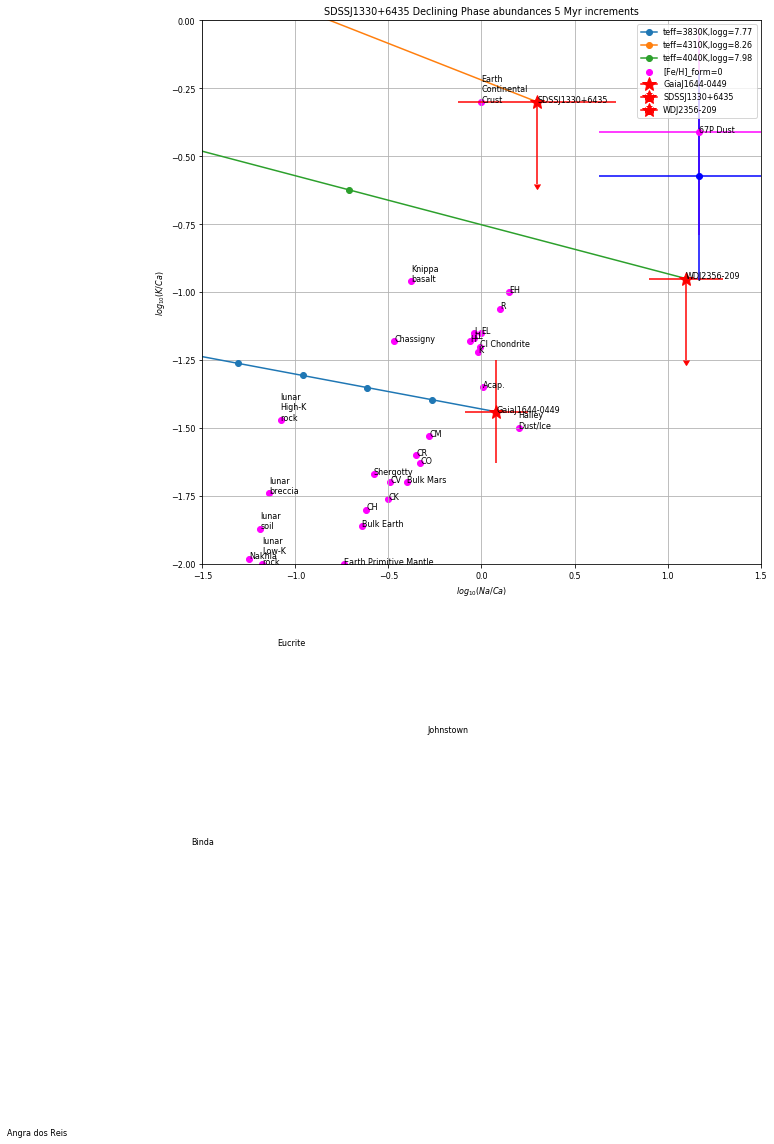

In [92]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
count=0
for j1644_row in wd_abund_table:
    print('\n\n',j1644_row['name'])
    if count==3:
        break
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker='*', markersize=14, color='r')
    else:
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker='*', color='r', markersize=14)
    plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
    acorr.el1el2_DP_el3el2_ftimes(j1644_row['teff'], j1644_row['li/ca'], j1644_row['na/ca'],1, 'Li', "Ca", "Na", logg=j1644_row['logg'])
    plt.text(j1644_row['na/ca'],j1644_row['k/ca'],j1644_row['name'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-1.5,1.5)
plt.ylim(-2,0.0)

plot_objects_KCaNa(do_timetravel=False)
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
plt.grid(True)
plt.show()








 GaiaJ1644-0449
Li log tau 7.10157493218
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [ 1.29606869  1.29606869  1.29606869  1.29606869  1.29606869  1.29606869
  1.29606869  1.29606869  1.29606869  1.29606869  1.29606869  1.29606869
  1.29606869  1.29606869  1.29606869  1.29606869  1.29606869  1.29606869
  1.29606869  1.29606869  1.29606869]

 SDSSJ1330+6435
Li log tau 5.62590159137
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [ 1.29739153  1.29739153  1.29739153  1.29739153  1.29739153  1.29739153
  1.29739153  1.29739153  1.29739153  1.29739153  1.29739153  1.29739153
  1.29739153  1.29739153  1.29739153  1.29739153  1.29739153  1.29739153
  1.29739153  1.29739153  1.29739153]

 WDJ2356-209
Li log tau 6.47302889884
Ca log tau 5.85997610257
Na log tau 6.26380115601
Slope: [ 1.2492052  1.2492052  1.2492052  1.2492052  1.2492052  1.2492052
  1.2492052  1.2492052  1.2492052  1.2492052  1.2492052  1.2492052
  1.2492052  1.2492052  1.2492052  1.2492052  1.2492052  1

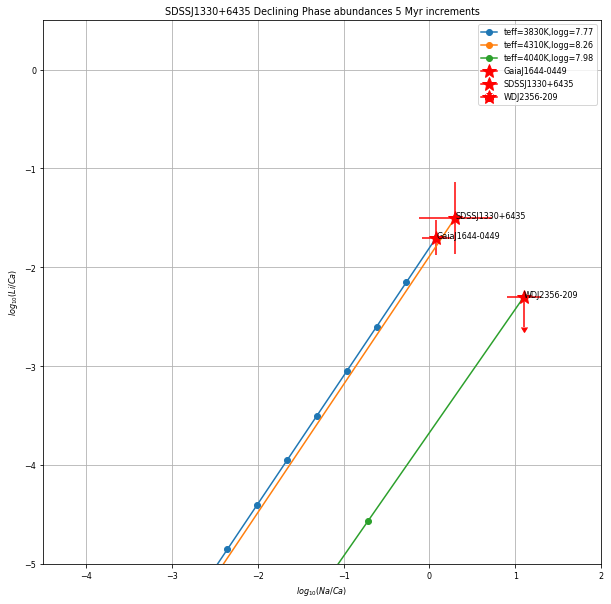

In [93]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
t_step=5
t_max=100
count=0
for j1644_row in wd_abund_table:
    print('\n',j1644_row['name'])
    if count==3:
        break
    if ((j1644_row['name']=='GaiaJ1644-0449') or (j1644_row['name']=='SDSSJ1330+6435')):
        plt.errorbar(j1644_row['na/ca'],j1644_row['li/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['li/ca_err'], label=j1644_row['name'], marker='*', markersize=14, color='r')
    else:
        plt.errorbar(j1644_row['na/ca'],j1644_row['li/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker='*', color='r', markersize=14)
    plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max, elements=['Li','Ca','Na'])
    plt.text(j1644_row['na/ca'],j1644_row['li/ca'],j1644_row['name'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-4.5,2)
plt.ylim(-5,0.5)
#plot_objects_KCaNa(do_timetravel=False)
plt.legend(loc='best')
plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(Li/Ca)$')
plt.grid(True)
plt.show()

# 2020-04-19 Making changes Chris wants for the final plot.

I'm going to redefine the plotting functions down here so the I can still make the old plots if I just run the whole notebook.

In [94]:
color_dict={
    'GaiaJ1644-0449':'r',
    'SDSSJ1330+6435':'darkviolet',
    'WDJ2356-209':'g'
}
step_dict={
    'GaiaJ1644-0449':10,
    'SDSSJ1330+6435':0.1,
    'WDJ2356-209':10
}

wd_marker='*'
met_marker='D'
met_color='#1ca1f2'
ci_size=14
wd_size=14
dp_alpha=1
arr_naca=[-0.4,-0.1]


##### Arrow on a line solution from Eric on stackoverflow https://stackoverflow.com/questions/34017866/arrow-on-a-line-plot-with-matplotlib


In [95]:
def add_arrow(line, position=None, direction='right', size=20, color=None, slope=None):
    """
    add an arrow to a line.

    line:       Line2D object
    position:   x-position of the arrow. If None, mean of xdata is taken
    direction:  'left' or 'right'
    size:       size of the arrow in fontsize points
    color:      if None, line color is taken.
    """
    if color is None:
        color = line.get_color()

    xdata = line.get_xdata()
    ydata = line.get_ydata()

    if position is None:
        position = xdata.mean()
    # find closest index
    start_ind = np.argmin(np.absolute(xdata - position))
    if direction == 'right':
        end_ind = start_ind + 1
    else:
        end_ind = start_ind - 1
    #xend=0.5*(xdata[end_ind]-xdata[start_ind])+xdata[start_ind]
    #yend=0.5*(ydata[end_ind]-ydata[end_ind])+ydata[start_ind]
    if slope is None:
        print('no slope...')
        xend=xdata[end_ind]
        yend=ydata[end_ind]
        xstart=xdata[start_ind]
        ystart=ydata[start_ind]
    else:
        #xend=0.5*(xdata[end_ind]-xdata[start_ind])+xdata[start_ind]
        xend=xdata[end_ind]
        #yend=slope*(xend-xdata[start_ind])+ydata[start_ind] #slope-intercept form that should work
        xstart=0.5*(xdata[start_ind]-xdata[end_ind])+xdata[end_ind]
        ystart=slope*(xstart-xdata[end_ind])+ydata[end_ind] #slope-intercept form that should work
    line.axes.annotate('',
        #xytext=(xdata[start_ind], ydata[start_ind]),
        xytext=(xstart,ystart),
        xy=(xdata[end_ind], ydata[end_ind]),
        #xy=(xend, yend),
        arrowprops=dict(arrowstyle="<|-", color=color),
        size=size
    )


In [96]:
#from Mashonkina et al. 2019 and the other Mashonkina et al. 2019/2020 paper that included thin disk stars as well.
npoints=100
FeH_thick= np.linspace(-1.5,-0.4,npoints)
FeH_halo=np.linspace(-2.6,-1.2,npoints)
FeH_thin= np.linspace(-0.73, 0.24, npoints)

#from later Mashonkina et al. 2019/2020 and our by-eye approximation of the trend
def get_CaFe_thin(FeH):
    slope=(0-0.24)/(0+0.7)
    #print(slope)
    return slope*FeH

#from Takeda 2020 for FGK dwarfs over the range 
def get_KFe_thin(FeH):
    #uncertainties: slope +/- 0.022, intercept +/- 0.005
    return -0.129*FeH -0.008

def get_KCa_thin(FeH):
    return get_KFe_thin(FeH)-get_CaFe_thin(FeH)

print(get_KCa_thin(np.min(FeH_thin)))

def plot_objects_KCaNa(do_timetravel=False):
    #plt.axvline(x=-0.68, linestyle=":", color='k', label='SDSSJ1636+1619 Det. Limit')
    various_naca_list=[
        #-1.1,-2.55,
                       -0.4, -0.01, -0.64,0.0, 0.2, -0.74,
                       #-0.58, -0.47, -1.25,
                      -0.28,-0.49, -0.33,-0.5,
                       #-0.06,-0.04,-0.04,
                       0.15,0.0,
                       #-1.19,-1.14,-1.08,-1.18,
                       #-0.38,
                       -0.35,-0.62,0.10,0.01,
        #-0.02,
                       #-1.56,-0.29
                      ]
    various_kca_list=[
        #-2.3,-4.1,
                      -1.7, -1.2,-1.86,-0.3, -1.5, -2.0,
                      #-1.67, -1.18, -1.98,
                     -1.53,-1.7,-1.63,-1.76,
                      #-1.18,-1.15,-1.17,
                      -1.0,-1.15,
                      #-1.87,-1.74,-1.47,-2.0,
                      #-0.96,
                      -1.60,-1.80,-1.06,-1.35,
        #-1.22,
                      #-3.03,-2.62
                     ]
    name_list=[
        #'Eucrite', 'Angra dos Reis',
               'Bulk Mars','CI Chondrite', 'Bulk Earth', "Earth\nContinental\nCrust","Comet Halley",
              "Earth Primitive Mantle", 
                #"Shergotty", "Chassigny", "Nakhla",
              "CM","CV","CO","CK",
               #"H","L","LL",
               "EH","EL",
               #"lunar\nsoil","lunar\nbreccia","lunar\nHigh-K\nrock","lunar\nLow-K\nrock",
               #"Knippa\nbasalt",
               "CR","CH","R","Acap.",
        #"K",
               #"Binda","Johnstown"
              ]
    P67_vals=[1.17, -0.41, 0.54, 0.38]
    max_KCa_off_thin=get_KCa_thin(np.nanmin(FeH_thin))

    #plt.scatter(various_naca_list,various_kca_list, color='magenta', label='various bodies')
    index_val=0
    for naca, kca, name in zip(various_naca_list, various_kca_list, name_list):
        if name=='CI Chondrite':
            #print('CI Chondrite caught')
            #plt.scatter(naca,kca, color=met_color, marker=met_marker, s=ci_size)
            plt.errorbar(naca,kca, color=met_color, marker=met_marker, markersize=ci_size, linestyle='None')
        elif index_val==0:
            #plt.scatter(naca,kca, color=met_color,marker=met_marker , label='[Fe/H]_form=0')
            plt.errorbar(naca,kca, color=met_color,marker=met_marker , label='[Fe/H]_form=0')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b', label='[Fe/H]_form=-0.73')
            else:
                pass
        else:
            #print('else statement')
            #print(name)
            #print('def in else statement\n')
            #plt.scatter(naca,kca, color=met_color, marker=met_marker)
            plt.errorbar(naca,kca, color=met_color, marker=met_marker, linestyle='None')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b')
            else:
                pass
        plt.text(naca, kca, name)
        index_val+=1
    
    
    plt.errorbar(P67_vals[0],P67_vals[1], xerr= P67_vals[2], yerr=P67_vals[3], color=met_color, marker=met_marker)
    if do_timetravel:
        plt.errorbar(P67_vals[0],P67_vals[1]+max_KCa_off_thin, xerr= P67_vals[2], yerr=P67_vals[3], color='b', marker='o')
    plt.text(P67_vals[0], P67_vals[1], "Comet 67P")
    return



-0.164115714286


In [97]:

def plot_wd_KCaNa(name, logg='default', teff='default', t_step=10, naca_min=-4.0, t_max=100, elements=["K","Ca","Na"]):
    """
    
    
    t_step=10, time in Myr of time-step for declining phase
    """
    string1= elements[0].lower()+'/'+elements[1].lower()
    string2=elements[2].lower()+'/'+elements[1].lower()
    #times= np.arange(0, t_max+t_step, t_step)
    times= np.arange(-1*t_max-t_step, t_max+t_step, t_step)
    target_row=wd_abund_table.loc[name]
    if logg=='default':
        logg=target_row['logg']
    else:
        pass
    if teff=='default':
        teff= target_row['teff']
    else:
        pass
    #dp_el1el2, dp_el3el2= acorr.el1el2_DP_el3el2_ftimes(teff, target_row['k/ca'], target_row['na/ca'],times, 'K', "Ca", "Na", logg=logg)
    dp_el1el2, dp_el3el2= acorr.el1el2_DP_el3el2_ftimes(teff, target_row[string1], target_row[string2],times, elements[0], elements[1], elements[2], logg=logg)
    line= plt.plot(dp_el3el2, dp_el1el2, marker='o', label="teff="+str(teff)+'K,logg='+str(logg), color=color_dict[name], alpha=dp_alpha)
    slope=(dp_el1el2-np.roll(dp_el1el2,1))/(dp_el3el2-np.roll(dp_el3el2,1))
    add_arrow(line[0],position=arr_naca[0], slope=slope[0])
    #t_nouse, arr_start=acorr.el1el2_DP_el3el2(teff, target_row[string1],target_row[string2], arr_naca[0],elements[0],elements[1],elements[2],logg=logg)
    #print(t_nouse)
    #t_nouse, arr_end=acorr.el1el2_DP_el3el2(teff, target_row[string1],target_row[string2], arr_naca[1],elements[0],elements[1],elements[2],logg=logg)
    #print(t_nouse)
    #plt.arrow(arr_naca[0], arr_start , arr_naca[1], arr_end-arr_start, shape='full', lw=1, length_includes_head=True, head_width=.05)
    #plt.plot(arr_naca,[arr_start,arr_end],color='b',marker='o')
    print('Slope:', slope)
    return



 GaiaJ1644-0449
K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467]


 SDSSJ1330+6435
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 ..., -0.26908603 -0.26908603
 -0.26908603]


 WDJ2356-209

skipping WDJ2356-209



 GaiaJ1644-0449_nM


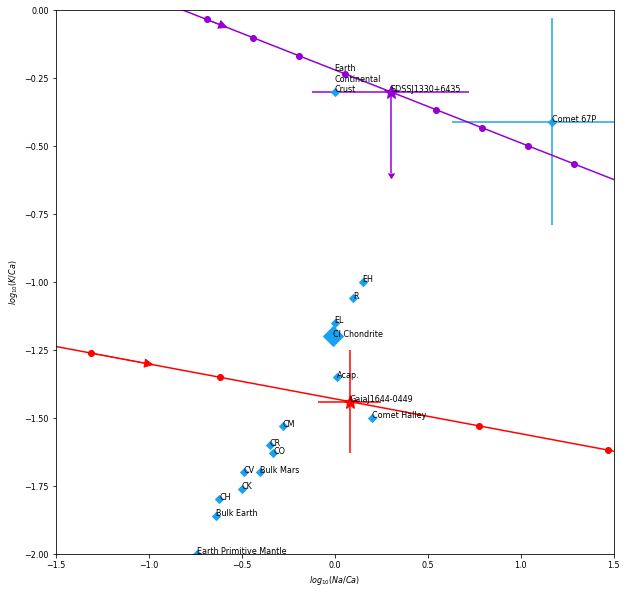

In [98]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
#t_step=1
t_max=100
count=0
for j1644_row in wd_abund_table:
    
    print('\n\n',j1644_row['name'])
    if count==3:
        break
    t_step=step_dict[j1644_row['name']]
    if j1644_row['name'] != 'WDJ2356-209': 
        plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
        plt.text(j1644_row['na/ca'],j1644_row['k/ca'],j1644_row['name'])
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker=wd_marker, markersize=wd_size, color=color_dict[j1644_row['name']])
    elif j1644_row['name']=='WDJ2356-209':
        print('\nskipping WDJ2356-209\n')
    else:
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker=wd_marker, color=color_dict[j1644_row['name']], markersize=wd_size)
    
    #acorr.el1el2_DP_el3el2_ftimes(j1644_row['teff'], j1644_row['li/ca'], j1644_row['na/ca'],1, 'Li', "Ca", "Na", logg=j1644_row['logg'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
plt.xlim(-1.5,1.5)
plt.ylim(-2,0.0)

plot_objects_KCaNa(do_timetravel=False)
#plt.legend(loc='best')
#plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
#plt.grid(True)
plt.show()








# 2020-04-22 Attempting to get the accreted masses in a consistent way

I'm going to redefine this equation down here to make it work for my next needs

In [99]:
def get_acc_mass_acorr(wd_name, dp=False, m_wd='default',desired_el1el2=0.0, el1='Na', el2="Ca", el1_mass_frac=0.1, el2_mass_frac=0.1, logg=8.0, cross_extrap=False):
    if m_wd=='default':
        m_wd=wd_abund_table.loc[wd_name]['m_wd']
    else:
        pass
    if dp:
        t_NaCa=acorr.get_time_since_accretion(wd_abund_table.loc[wd_name]['teff'],wd_abund_table.loc[wd_name]['na/ca'], desired_NaCa,'Na', 'Ca',logg=logg ,cross_extrap=cross_extrap)
        log_mCa= acorr.get_accreted_mass('Ca', wd_abund_table.loc[wd_name]['ca/he'], t_NaCa,  teff=wd_abund_table.loc[wd_name]['teff'], logg=logg, log_q=wd_abund_table.loc[wd_name]['log_q'], m_wd=m_wd, cross_extrap=cross_extrap)
        log_mNa= acorr.get_accreted_mass('Na', wd_abund_table.loc[wd_name]['na/he'], t_NaCa,  teff=wd_abund_table.loc[wd_name]['teff'], logg=logg, log_q=wd_abund_table.loc[wd_name]['log_q'], m_wd=m_wd, cross_extrap=cross_extrap)
        
    else:
        m_wd= (m_wd*const.M_sun).to(u.kg).value
        el_num=cp.el_nums[el]
        log_elHe
        log_m_acc= np.log10(pt.elements[el_num].mass/pt.elements[2].mass)+log_elHe+log_q+np.log10(m_wd)+(t_passed/(10.**log_el_tau))*np.log10(np.e)
    mel1=10**log_mel1
    mCa=10**log_mCa
    mtotal_from_Na= mNa/Na_mass_frac
    mtotal_from_Ca= mCa/Ca_mass_frac
    print('\nName:',wd_name)
    print('time since accretion', t_NaCa*1e-6, 'Myr')
    print('total accreted mass from Na', mtotal_from_Na, 'kg')
    print('total accreted mass from Ca', mtotal_from_Ca, 'kg')
    print('log(Na/Ca) worked back',np.log10(pt.elements[cp.el_nums['Ca']].mass/pt.elements[cp.el_nums['Na']].mass*mNa/mCa))
    print('desired_NaCa', desired_NaCa)
    #print('so those should be the same...')
    return mtotal_from_Ca

Actually fuck that. I'm just doing the faster way, which I was already geared to do... fucking idiot.

In [100]:
j1644_mHe= 10.**wd_abund_table.loc['GaiaJ1644-0449']['log_q']*0.45 *u.solMass

j1644_mCa= 10**wd_abund_table.loc['GaiaJ1644-0449']['ca/he'] * j1644_mHe

j1644_mAcc_chond=j1644_mCa/(9220./1e6)



Ok that code I pulled from way earlier in the notebook was unsurprisingly wrong. I have redone the math though, which is mostly comprised of unit conversions

In [101]:
def log_m_acc(row, el='Ca', f_el=(9220./1e6)):
    el_num=cp.el_nums[el]
    return row[el.lower()+'/he']+np.log10(pt.elements[el_num].mass/pt.elements[2].mass)+np.log10(row['m_wd'])+row['log_q']-np.log10(f_el)

In [102]:
element_mass='Ca'
for row in wd_abund_table:
    log_mass= log_m_acc(row, el=element_mass)
    mass_accreted= ((10**log_mass)*const.M_sun).to(u.kg)
    print('\nname:',row['name'])
    print('WD Mass', row['m_wd'])
    print('Mass of Accreted Body (assuming Early Phase and CI chond. Ca mass frac)', mass_accreted)
    print('\n')
    


name: GaiaJ1644-0449
WD Mass 0.45
Mass of Accreted Body (assuming Early Phase and CI chond. Ca mass frac) 1.31088758839e+19 kg



name: SDSSJ1330+6435
WD Mass 0.74
Mass of Accreted Body (assuming Early Phase and CI chond. Ca mass frac) 1.13131789687e+20 kg



name: WDJ2356-209
WD Mass 0.56
Mass of Accreted Body (assuming Early Phase and CI chond. Ca mass frac) 2.70732856029e+18 kg



name: GaiaJ1644-0449_nM
WD Mass 0.56
Mass of Accreted Body (assuming Early Phase and CI chond. Ca mass frac) 5.04128168684e+18 kg




## 2020-08-13 Adding SDSS J1636+1619 to the log(K/Ca) vs. log(Na/Ca) plot

We got Gemini observations of SDSS J1636+1619 and Simon calculated limits on the abundances of lithium and potassium from it. He found $log(Li/Ca) \leq -1.8$ and $log(K/Ca) \leq -0.4$. Hollands et al 2017 also appears to be the only one that calculated (and published) a sodium limit, so from the MWDD, he reported $log(Na/He) \leq -10.18$, and his $$log(Ca/He) = -9.5$$ matches up with Simon's own reported value from his Magnesium paper (Blouin 2020). Therefore, $log(Na/Ca) \leq -0.68$ for our purposes

Actually Simon wrote back saying "Hollands et al. give log Na/He = -10.18 for J1636. I don't know how they got this number. Even with the Gemini spectrum (so let alone the SDSS spectrum used in Hollands et al.), I think we can only put an upper limit on the Na abundance. Something like log Na/He < -9.9 appears reasonable (see attached plot)."

So I'll change to Simon's new number, which means $log(Na/Ca) \leq -0.4$

In [103]:
#from Mashonkina et al. 2019 and the other Mashonkina et al. 2019/2020 paper that included thin disk stars as well.
npoints=100
FeH_thick= np.linspace(-1.5,-0.4,npoints)
FeH_halo=np.linspace(-2.6,-1.2,npoints)
FeH_thin= np.linspace(-0.73, 0.24, npoints)

#from later Mashonkina et al. 2019/2020 and our by-eye approximation of the trend
def get_CaFe_thin(FeH):
    slope=(0-0.24)/(0+0.7)
    #print(slope)
    return slope*FeH

#from Takeda 2020 for FGK dwarfs over the range 
def get_KFe_thin(FeH):
    #uncertainties: slope +/- 0.022, intercept +/- 0.005
    return -0.129*FeH -0.008

def get_KCa_thin(FeH):
    return get_KFe_thin(FeH)-get_CaFe_thin(FeH)

print(get_KCa_thin(np.min(FeH_thin)))

def plot_objects_KCaNa(do_timetravel=False):
    #plt.axvline(x=-0.68, linestyle=":", color='k', label='SDSSJ1636+1619 Det. Limit')
    various_naca_list=[
        -1.1,#-2.55,
                       -0.4, -0.01, -0.64,0.0, 0.2, -0.74,
                       #-0.58, -0.47, -1.25,
                      -0.28,-0.49, -0.33,-0.5,
                       #-0.06,-0.04,-0.04,
                       0.15,0.0,
                       #-1.19,-1.14,-1.08,-1.18,
                       #-0.38,
                       -0.35,-0.62,0.10,0.01,
        #-0.02,
                       #-1.56,-0.29
                      ]
    various_kca_list=[
        -2.3,#-4.1,
                      -1.7, -1.2,-1.86,-0.3, -1.5, -2.0,
                      #-1.67, -1.18, -1.98,
                     -1.53,-1.7,-1.63,-1.76,
                      #-1.18,-1.15,-1.17,
                      -1.0,-1.15,
                      #-1.87,-1.74,-1.47,-2.0,
                      #-0.96,
                      -1.60,-1.80,-1.06,-1.35,
        #-1.22,
                      #-3.03,-2.62
                     ]
    name_list=[
        'Eucrite',# 'Angra dos Reis',
               'Bulk Mars','CI Chondrite', 'Bulk Earth', "Earth\nContinental\nCrust","Comet Halley",
              "Earth Primitive Mantle", 
                #"Shergotty", "Chassigny", "Nakhla",
              "CM","CV","CO","CK",
               #"H","L","LL",
               "EH","EL",
               #"lunar\nsoil","lunar\nbreccia","lunar\nHigh-K\nrock","lunar\nLow-K\nrock",
               #"Knippa\nbasalt",
               "CR","CH","R","Acap.",
        #"K",
               #"Binda","Johnstown"
              ]
    P67_vals=[1.17, -0.41, 0.54, 0.38]
    max_KCa_off_thin=get_KCa_thin(np.nanmin(FeH_thin))

    #plt.scatter(various_naca_list,various_kca_list, color='magenta', label='various bodies')
    index_val=0
    for naca, kca, name in zip(various_naca_list, various_kca_list, name_list):
        if name=='CI Chondrite':
            #print('CI Chondrite caught')
            #plt.scatter(naca,kca, color=met_color, marker=met_marker, s=ci_size)
            plt.errorbar(naca,kca, color=met_color, marker=met_marker, markersize=ci_size, linestyle='None')
        elif index_val==0:
            #plt.scatter(naca,kca, color=met_color,marker=met_marker , label='[Fe/H]_form=0')
            plt.errorbar(naca,kca, color=met_color,marker=met_marker , label='[Fe/H]_form=0')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b', label='[Fe/H]_form=-0.73')
            else:
                pass
        else:
            #print('else statement')
            #print(name)
            #print('def in else statement\n')
            #plt.scatter(naca,kca, color=met_color, marker=met_marker)
            plt.errorbar(naca,kca, color=met_color, marker=met_marker, linestyle='None')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b')
            else:
                pass
        plt.text(naca, kca, name)
        index_val+=1
    
    
    plt.errorbar(P67_vals[0],P67_vals[1], xerr= P67_vals[2], yerr=P67_vals[3], color=met_color, marker=met_marker)
    if do_timetravel:
        plt.errorbar(P67_vals[0],P67_vals[1]+max_KCa_off_thin, xerr= P67_vals[2], yerr=P67_vals[3], color='b', marker='o')
    plt.text(P67_vals[0], P67_vals[1], "Comet 67P")
    return




-0.164115714286




 GaiaJ1644-0449
K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467]


 SDSSJ1330+6435
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 ..., -0.26908603 -0.26908603
 -0.26908603]


 WDJ2356-209

skipping WDJ2356-209



 GaiaJ1644-0449_nM


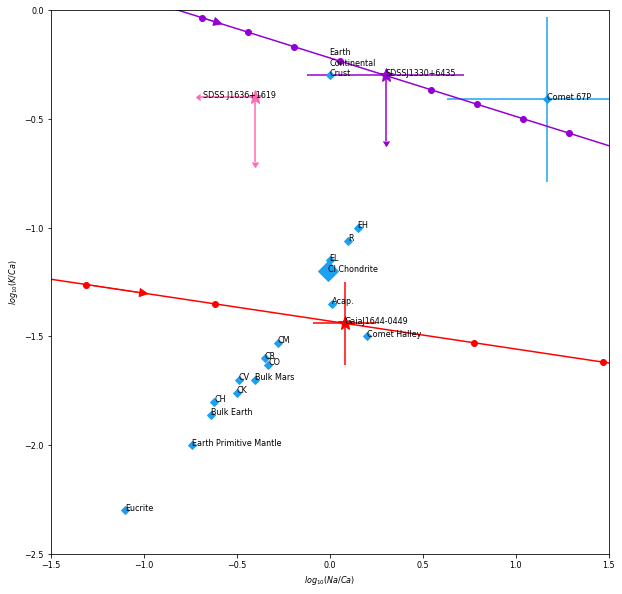

In [104]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
#t_step=1
t_max=100
count=0
for j1644_row in wd_abund_table:
    
    print('\n\n',j1644_row['name'])
    if count==3:
        break
    t_step=step_dict[j1644_row['name']]
    if j1644_row['name'] != 'WDJ2356-209': 
        plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max)
        plt.text(j1644_row['na/ca'],j1644_row['k/ca'],j1644_row['name'])
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker=wd_marker, markersize=wd_size, color=color_dict[j1644_row['name']])
    elif j1644_row['name']=='WDJ2356-209':
        print('\nskipping WDJ2356-209\n')
    else:
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker=wd_marker, color=color_dict[j1644_row['name']], markersize=wd_size)
    
    #acorr.el1el2_DP_el3el2_ftimes(j1644_row['teff'], j1644_row['li/ca'], j1644_row['na/ca'],1, 'Li', "Ca", "Na", logg=j1644_row['logg'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
#plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker=wd_marker, color=color_dict[j1644_row['name']], markersize=wd_size)
plt.errorbar(-0.4, -0.4, xerr=0.3, yerr=0.3, xuplims=True, uplims=True, marker=wd_marker, color='hotpink',markersize=wd_size )
plt.text(-0.68,-0.4,"SDSS J1636+1619")
plt.xlim(-1.5,1.5)
#plt.ylim(-2,0.0)
plt.ylim(-2.5,0.0)



plot_objects_KCaNa(do_timetravel=False)
#plt.legend(loc='best')
#plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
#plt.grid(True)
plt.show()




## 2020-08-27 Trying out the changes to make the arrow just point as the only indication of declining phase

This is the function to change. I basically need to add an option that lets me specify a timestep as a tau value instead of a specific number. Once I have that down, I can then go about figuring out how to make the thing actually stamp an arrow on the plot instead of our current line method.

No I need to make it still be a number as an input. What I need to do though is make another kwarg that specifies the "units" of t_step. i.e. is it in units of "Ca", meaning multiples of the diffusion timescale of Ca or is it "Myr" meaning just the default input numbers

is it $10^{\tau}$ that yields correct units of time or is it $e^{\tau}$ ? I cannot recall at the moment and I'd say that is relatively important... I feel like it would make the most sense for it to be base 10... Perhaps Fontaine mentioned it? Ah it's actually irrelevant (-ish) because Koester 2009 puts it in $e^{-t/\tau}$, but the problem is the tau values themselves are provided as "the logarithm of the timescales in years for the elements" at least in Koester, but it's probably safe to assume Fontaine followed the same convention and I think it's safe to assume those are base 10.

In [115]:
color_dict={
    'GaiaJ1644-0449':'r',
    'SDSSJ1330+6435':'darkviolet',
    'WDJ2356-209':'g'
}
step_dict={
    'GaiaJ1644-0449':1,
    'SDSSJ1330+6435':1,
    'WDJ2356-209':1
}

wd_marker='*'
met_marker='D'
met_color='#1ca1f2'
ci_size=14
wd_size=14
dp_alpha=1
arr_naca=[-0.4,-0.1]



In [116]:
def add_arrow(line, position=None, direction='right', size=20, color=None, slope=None):
    """
    add an arrow to a line.

    line:       Line2D object
    position:   x-position of the arrow. If None, mean of xdata is taken
    direction:  'left' or 'right'
    size:       size of the arrow in fontsize points
    color:      if None, line color is taken.
    """
    if color is None:
        color = line.get_color()

    xdata = line.get_xdata()
    ydata = line.get_ydata()

    if position is None:
        position = xdata.mean()
    # find closest index
    start_ind = np.argmin(np.absolute(xdata - position))
    if direction == 'right':
        end_ind = start_ind + 1
    else:
        end_ind = start_ind - 1
    #xend=0.5*(xdata[end_ind]-xdata[start_ind])+xdata[start_ind]
    #yend=0.5*(ydata[end_ind]-ydata[end_ind])+ydata[start_ind]
    if slope is None:
        print('no slope...')
        xend=xdata[end_ind]
        yend=ydata[end_ind]
        xstart=xdata[start_ind]
        ystart=ydata[start_ind]
    else:
        #xend=0.5*(xdata[end_ind]-xdata[start_ind])+xdata[start_ind]
        xend=xdata[end_ind]
        #yend=slope*(xend-xdata[start_ind])+ydata[start_ind] #slope-intercept form that should work
        xstart=0.5*(xdata[start_ind]-xdata[end_ind])+xdata[end_ind]
        ystart=slope*(xstart-xdata[end_ind])+ydata[end_ind] #slope-intercept form that should work
    line.axes.annotate('',
        #xytext=(xdata[start_ind], ydata[start_ind]),
        xytext=(xstart,ystart),
        xy=(xdata[end_ind], ydata[end_ind]),
        #xy=(xend, yend),
        arrowprops=dict(arrowstyle="<|-", color=color),
        size=size
    )



In [117]:

def plot_wd_KCaNa(name, logg='default', teff='default', t_step=10, naca_min=-4.0, t_max=100, elements=["K","Ca","Na"], t_step_units='Myr'):
    """
    
    
    t_step=10, time in Myr of time-step for declining phase
    
    
    """
    
    string1= elements[0].lower()+'/'+elements[1].lower()
    string2=elements[2].lower()+'/'+elements[1].lower()
    #times= np.arange(0, t_max+t_step, t_step)
    
    
    target_row=wd_abund_table.loc[name]
    if logg=='default':
        logg=target_row['logg']
    else:
        pass
    if teff=='default':
        teff= target_row['teff']
    else:
        pass
    if t_step_units != 'Myr':
        print("t_step_units is not Myr, meaning it's some diffusion timescale multiple")
        print('so t_step= ',t_step,"* tau_",t_step_units)
        tau_time= 10.**itau.extrapolate_tau_x_logg(teff, logg, t_step_units)
        tau_time=tau_time*1e-6 #converted to Myr
        t_step=t_step*tau_time
        t_max=t_max*tau_time
        print('New t_step:',t_step, 'Myr')
        print('New t_max:', t_max, 'Myr')
    else:
        pass
    times= np.arange(-1*t_max-t_step, t_max+t_step, t_step)
    #dp_el1el2, dp_el3el2= acorr.el1el2_DP_el3el2_ftimes(teff, target_row['k/ca'], target_row['na/ca'],times, 'K', "Ca", "Na", logg=logg)
    dp_el1el2, dp_el3el2= acorr.el1el2_DP_el3el2_ftimes(teff, target_row[string1], target_row[string2],times, elements[0], elements[1], elements[2], logg=logg)
    line= plt.plot(dp_el3el2, dp_el1el2, marker='o', label="teff="+str(teff)+'K,logg='+str(logg), color=color_dict[name], alpha=dp_alpha)
    slope=(dp_el1el2-np.roll(dp_el1el2,1))/(dp_el3el2-np.roll(dp_el3el2,1))
    add_arrow(line[0],position=arr_naca[0], slope=slope[0])
    #t_nouse, arr_start=acorr.el1el2_DP_el3el2(teff, target_row[string1],target_row[string2], arr_naca[0],elements[0],elements[1],elements[2],logg=logg)
    #print(t_nouse)
    #t_nouse, arr_end=acorr.el1el2_DP_el3el2(teff, target_row[string1],target_row[string2], arr_naca[1],elements[0],elements[1],elements[2],logg=logg)
    #print(t_nouse)
    #plt.arrow(arr_naca[0], arr_start , arr_naca[1], arr_end-arr_start, shape='full', lw=1, length_includes_head=True, head_width=.05)
    #plt.plot(arr_naca,[arr_start,arr_end],color='b',marker='o')
    print('Slope:', slope)
    return

In [118]:
#from Mashonkina et al. 2019 and the other Mashonkina et al. 2019/2020 paper that included thin disk stars as well.
npoints=100
FeH_thick= np.linspace(-1.5,-0.4,npoints)
FeH_halo=np.linspace(-2.6,-1.2,npoints)
FeH_thin= np.linspace(-0.73, 0.24, npoints)

#from later Mashonkina et al. 2019/2020 and our by-eye approximation of the trend
def get_CaFe_thin(FeH):
    slope=(0-0.24)/(0+0.7)
    #print(slope)
    return slope*FeH

#from Takeda 2020 for FGK dwarfs over the range 
def get_KFe_thin(FeH):
    #uncertainties: slope +/- 0.022, intercept +/- 0.005
    return -0.129*FeH -0.008

def get_KCa_thin(FeH):
    return get_KFe_thin(FeH)-get_CaFe_thin(FeH)

print(get_KCa_thin(np.min(FeH_thin)))

def plot_objects_KCaNa(do_timetravel=False):
    #plt.axvline(x=-0.68, linestyle=":", color='k', label='SDSSJ1636+1619 Det. Limit')
    various_naca_list=[
        -1.1,#-2.55,
                       -0.4, -0.01, -0.64,0.0, 0.2, -0.74,
                       #-0.58, -0.47, -1.25,
                      -0.28,-0.49, -0.33,-0.5,
                       #-0.06,-0.04,-0.04,
                       0.15,0.0,
                       #-1.19,-1.14,-1.08,-1.18,
                       #-0.38,
                       -0.35,-0.62,0.10,0.01,
        #-0.02,
                       #-1.56,-0.29
                      ]
    various_kca_list=[
        -2.3,#-4.1,
                      -1.7, -1.2,-1.86,-0.3, -1.5, -2.0,
                      #-1.67, -1.18, -1.98,
                     -1.53,-1.7,-1.63,-1.76,
                      #-1.18,-1.15,-1.17,
                      -1.0,-1.15,
                      #-1.87,-1.74,-1.47,-2.0,
                      #-0.96,
                      -1.60,-1.80,-1.06,-1.35,
        #-1.22,
                      #-3.03,-2.62
                     ]
    name_list=[
        'Eucrite',# 'Angra dos Reis',
               'Bulk Mars','CI Chondrite', 'Bulk Earth', "Earth\nContinental\nCrust","Comet Halley",
              "Earth Primitive Mantle", 
                #"Shergotty", "Chassigny", "Nakhla",
              "CM","CV","CO","CK",
               #"H","L","LL",
               "EH","EL",
               #"lunar\nsoil","lunar\nbreccia","lunar\nHigh-K\nrock","lunar\nLow-K\nrock",
               #"Knippa\nbasalt",
               "CR","CH","R","Acap.",
        #"K",
               #"Binda","Johnstown"
              ]
    P67_vals=[1.17, -0.41, 0.54, 0.38]
    max_KCa_off_thin=get_KCa_thin(np.nanmin(FeH_thin))

    #plt.scatter(various_naca_list,various_kca_list, color='magenta', label='various bodies')
    index_val=0
    for naca, kca, name in zip(various_naca_list, various_kca_list, name_list):
        if name=='CI Chondrite':
            #print('CI Chondrite caught')
            #plt.scatter(naca,kca, color=met_color, marker=met_marker, s=ci_size)
            plt.errorbar(naca,kca, color=met_color, marker=met_marker, markersize=ci_size, linestyle='None')
        elif index_val==0:
            #plt.scatter(naca,kca, color=met_color,marker=met_marker , label='[Fe/H]_form=0')
            plt.errorbar(naca,kca, color=met_color,marker=met_marker , label='[Fe/H]_form=0')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b', label='[Fe/H]_form=-0.73')
            else:
                pass
        else:
            #print('else statement')
            #print(name)
            #print('def in else statement\n')
            #plt.scatter(naca,kca, color=met_color, marker=met_marker)
            plt.errorbar(naca,kca, color=met_color, marker=met_marker, linestyle='None')
            if do_timetravel:
                plt.scatter(naca,kca+max_KCa_off_thin, color='b')
            else:
                pass
        plt.text(naca, kca, name)
        index_val+=1
    
    
    plt.errorbar(P67_vals[0],P67_vals[1], xerr= P67_vals[2], yerr=P67_vals[3], color=met_color, marker=met_marker)
    if do_timetravel:
        plt.errorbar(P67_vals[0],P67_vals[1]+max_KCa_off_thin, xerr= P67_vals[2], yerr=P67_vals[3], color='b', marker='o')
    plt.text(P67_vals[0], P67_vals[1], "Comet 67P")
    return





-0.164115714286




 GaiaJ1644-0449
t_step_units is not Myr, meaning it's some diffusion timescale multiple
so t_step=  1 * tau_ Ca
New t_step: 3.49012687154 Myr
New t_max: 34.9012687154 Myr
K log tau 6.51277010357
Ca log tau 6.54284121453
Na log tau 6.89784868157
Slope: [-0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467 -0.12838467
 -0.12838467 -0.12838467 -0.12838467 -0.12838467]


 SDSSJ1330+6435
t_step_units is not Myr, meaning it's some diffusion timescale multiple
so t_step=  1 * tau_ Ca
New t_step: 0.102622451911 Myr
New t_max: 1.02622451911 Myr
K log tau 4.94789525304
Ca log tau 5.01124238684
Na log tau 5.39172426907
Slope: [-0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603 -0.26908603
 -0

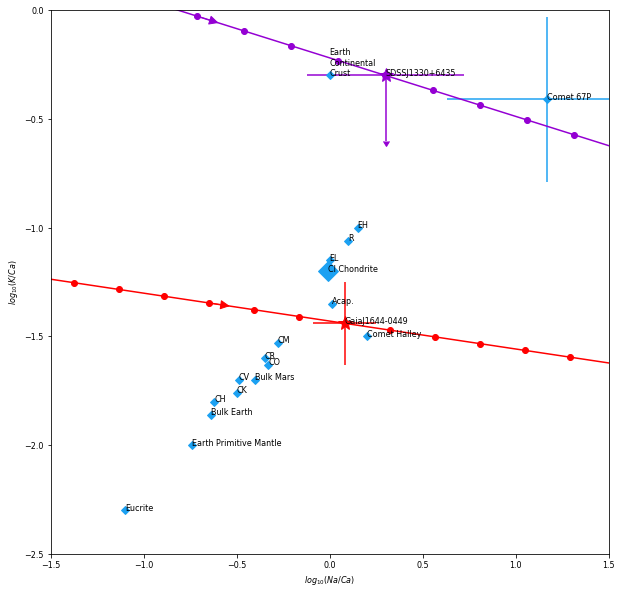

In [120]:
wd_name='SDSSJ1330+6435'
j1644_row=wd_abund_table.loc[wd_name]
plt.figure(figsize=(10,10))
#naca_line=np.linspace(-4, 0.0, 40)
#t_step=1
t_max=10
count=0
for j1644_row in wd_abund_table:
    
    print('\n\n',j1644_row['name'])
    if count==3:
        break
    t_step=step_dict[j1644_row['name']]
    if j1644_row['name'] != 'WDJ2356-209': 
        plot_wd_KCaNa(j1644_row['name'], logg='default', t_step=t_step, naca_min=-4.0, t_max=t_max, t_step_units='Ca')
        plt.text(j1644_row['na/ca'],j1644_row['k/ca'],j1644_row['name'])
    if j1644_row['name']=='GaiaJ1644-0449':
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=j1644_row['k/ca_err'], label='GaiaJ1644-0449', marker=wd_marker, markersize=wd_size, color=color_dict[j1644_row['name']])
    elif j1644_row['name']=='WDJ2356-209':
        print('\nskipping WDJ2356-209\n')
    else:
        plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker=wd_marker, color=color_dict[j1644_row['name']], markersize=wd_size)
    
    #acorr.el1el2_DP_el3el2_ftimes(j1644_row['teff'], j1644_row['li/ca'], j1644_row['na/ca'],1, 'Li', "Ca", "Na", logg=j1644_row['logg'])
    count+=1
#plot_wd_KCaNa(wd_name, teff=4200, t_step=t_step, naca_min=-4.0, t_max=t_max)
#plt.errorbar(j1644_row['na/ca'],j1644_row['k/ca'],xerr=j1644_row['na/ca_err'],yerr=0.3, uplims=True,label=j1644_row['name'], marker=wd_marker, color=color_dict[j1644_row['name']], markersize=wd_size)

plt.xlim(-1.5,1.5)
#plt.ylim(-2,0.0)
plt.ylim(-2.5,0.0)



plot_objects_KCaNa(do_timetravel=False)
#plt.legend(loc='best')
#plt.title(wd_name+' Declining Phase abundances '+str(t_step)+" Myr increments")
plt.xlabel(r'$log_{10}(Na/Ca)$')
plt.ylabel(r'$log_{10}(K/Ca)$')
#plt.grid(True)
plt.show()



